In [1]:
import gffpandas.gffpandas as gffpd
import pandas as pd
import numpy as np

In [2]:
ctrl_ph7 = gffpd.read_gff3('../sample1_modification.gff') #Wild Type pH 7
arss_ph7 = gffpd.read_gff3('../sample2_modification.gff') #ArsS deletion pH 7, cannot detect pH change
ctrl_ph5 = gffpd.read_gff3('../sample5_modification.gff') #wild type pH 5
arss_ph5 = gffpd.read_gff3('../sample6_modification.gff') #ArsS deletion pH 5

In [8]:
annot = pd.read_csv("../hpy_annot.tsv",sep='\t')#hpy annotation file
annot = annot.drop(columns=["seqname", "source", "feature", "score", "frame", "Prot_Size(est)", "attribute"]) #clean
tss = pd.read_csv("../TSS.csv")

gene_counts = pd.read_csv("gene_counts.csv")

In [3]:
ctrl_ph7 = ctrl_ph7.attributes_to_columns()
ctrl_ph5 = ctrl_ph5.attributes_to_columns()

arss_ph7 = arss_ph7.attributes_to_columns()
arss_ph5 = arss_ph5.attributes_to_columns()

In [4]:
ctrl_ph7 = ctrl_ph7[ctrl_ph7['IPDRatio'] >= '2']
ctrl_ph5 = ctrl_ph5[ctrl_ph5['IPDRatio'] >= '2']

arss_ph7 = arss_ph7[arss_ph7['IPDRatio'] >= '2']
arss_ph5 = arss_ph5[arss_ph5['IPDRatio'] >= '2']

In [5]:
# merging samples
frames = [ctrl_ph7, ctrl_ph5, arss_ph7, arss_ph5]
keys = ['ctrl pH7', 'ctrl pH5', 'arsS pH7', 'arsS pH5']
merged = pd.concat(frames, keys = keys)
merged = merged.reset_index(level=0).rename(columns={'level_0': 'sample'})
merged

,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif
1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535,GAGG
2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656,GANTC
3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597,GANTC
6,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695,RCGDAD
12,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738,RCGDAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82780,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.54,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663,GATC
82782,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.78,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447,DGAAGG
82783,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.39,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451,RCGDAD
82784,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.19,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644,GAAGA


In [2]:
merged = pd.read_csv('merged_final.csv')

In [3]:
merged

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
0,0,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535.0,GAGG,intergenic region,NaN,NaN
1,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,coding region,HP0001,TRANSCRIPTION
2,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,coding region,HP0001,TRANSCRIPTION
3,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
4,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237125,237125,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.54,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663.0,GATC,coding region,HP1589,HYPOTHETICAL PROTEIEN
237126,237126,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.78,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447.0,DGAAGG,coding region,HP1589,HYPOTHETICAL PROTEIEN
237127,237127,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.39,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451.0,RCGDAD,coding region,HP1589,HYPOTHETICAL PROTEIEN
237128,237128,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.19,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644.0,GAAGA,coding region,HP1590,HYPOTHETICAL PROTEIEN


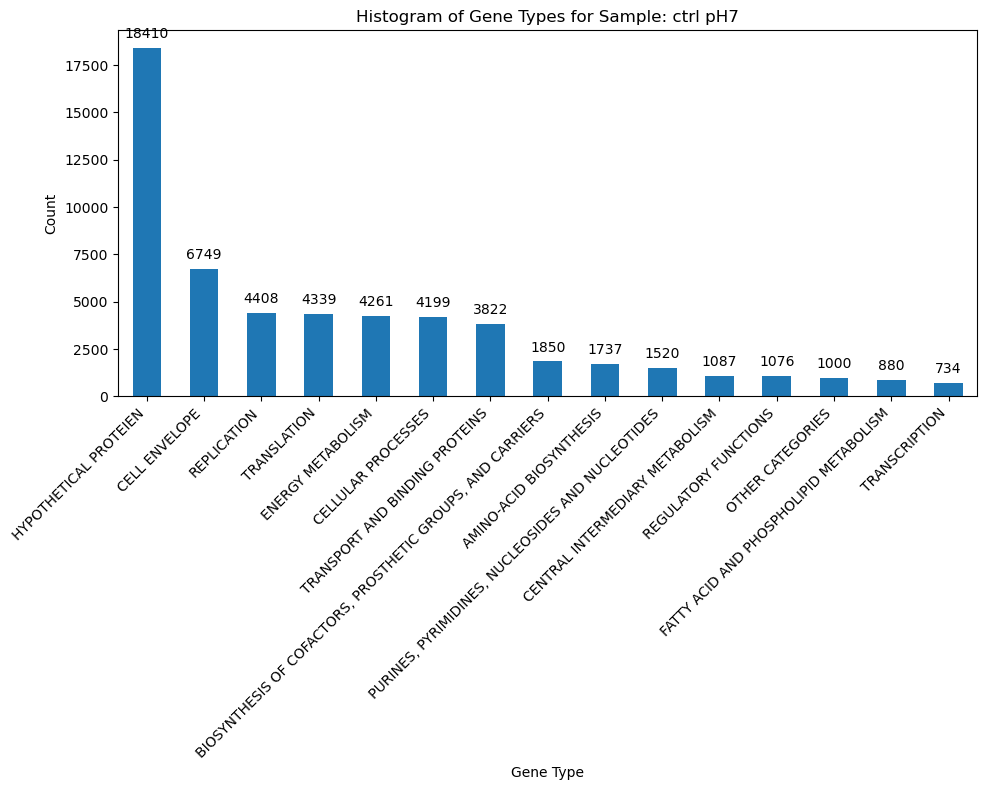

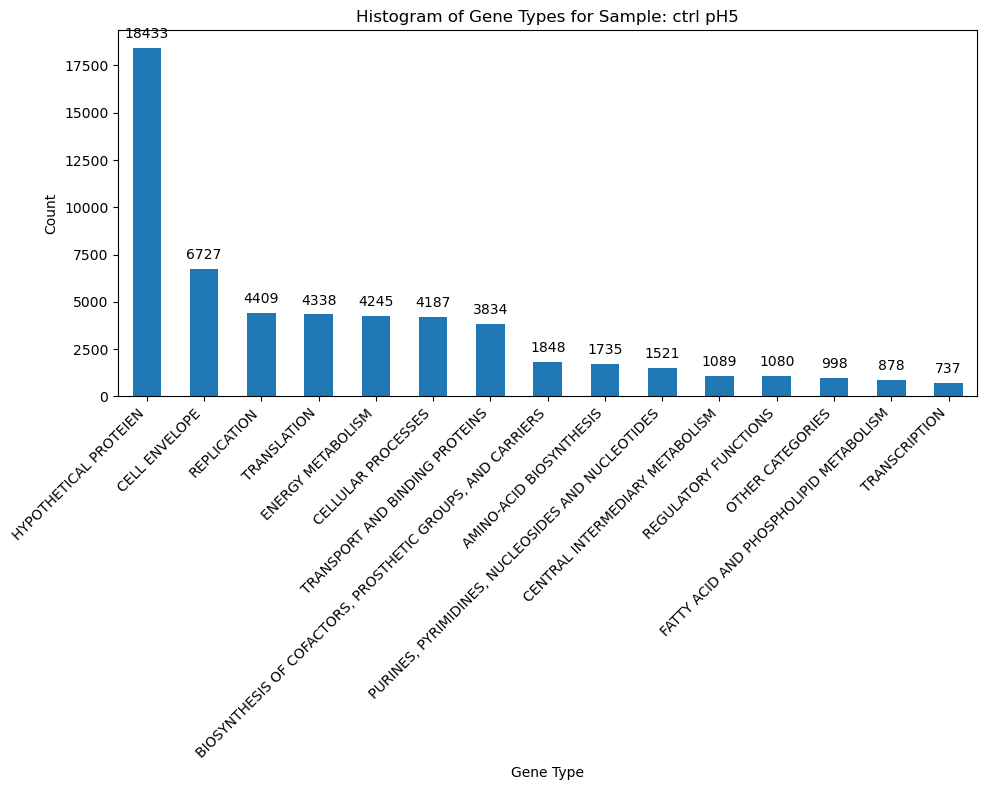

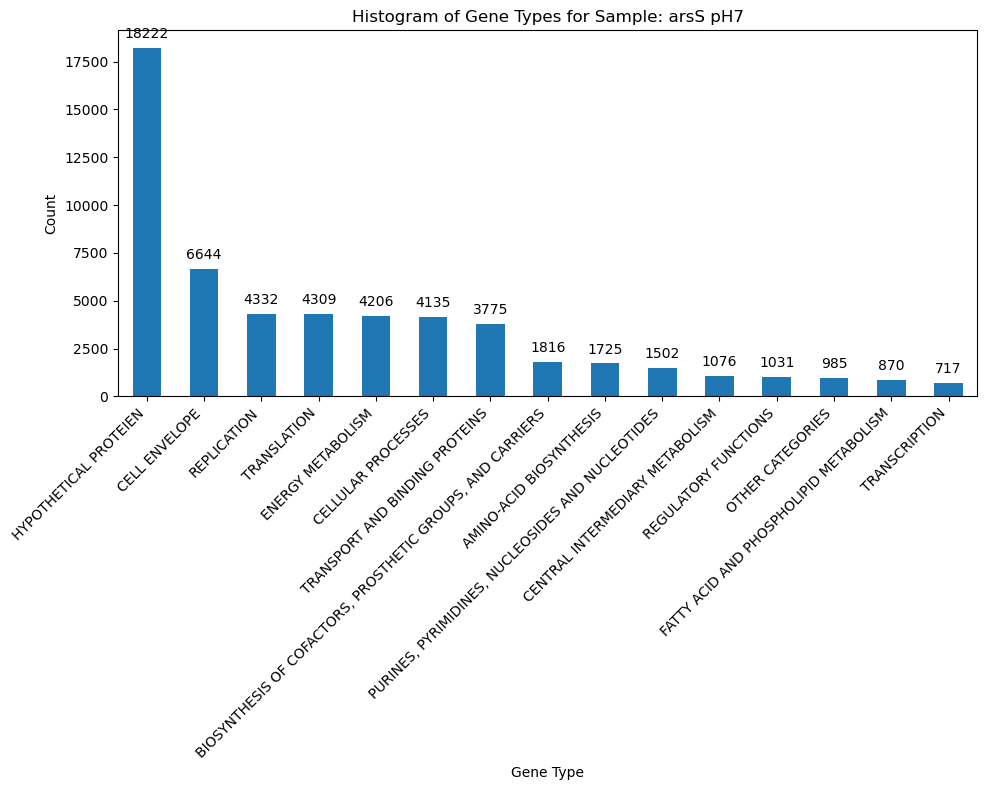

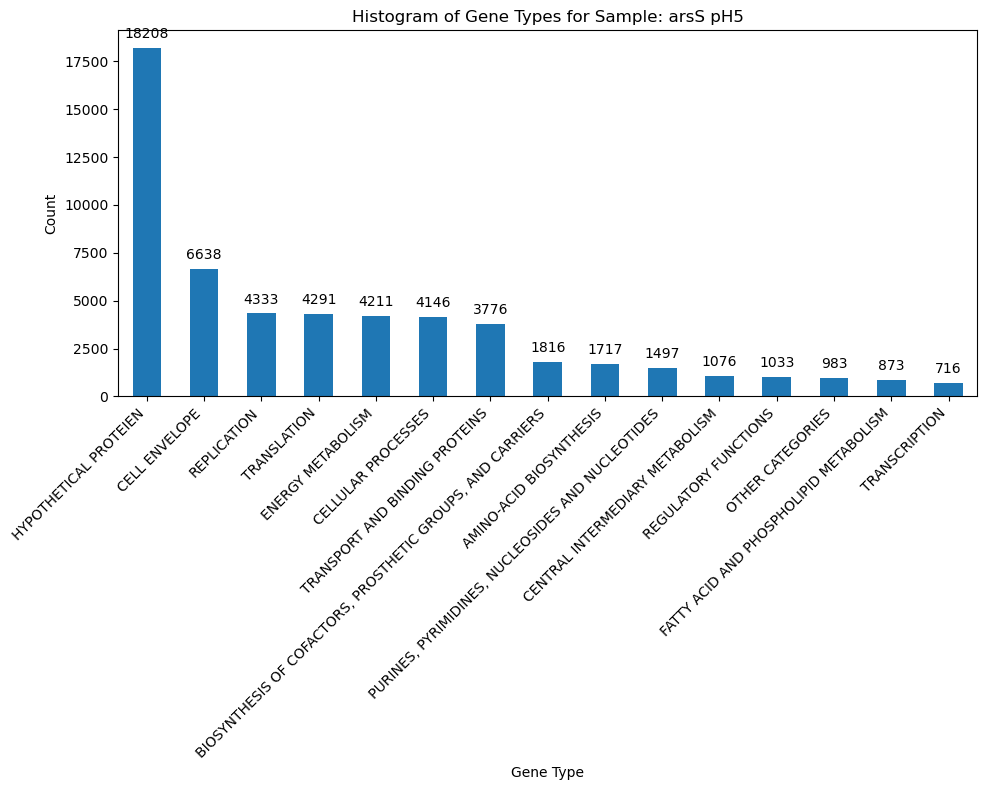

In [4]:
import matplotlib.pyplot as plt
unique_samples = merged['sample'].unique()

for sample in unique_samples:
    sample_data = merged[merged['sample'] == sample]
    gene_type_counts = sample_data['gene_type'].value_counts()
    
    plt.figure(figsize=(10, 8))
    ax = gene_type_counts.plot(kind='bar')
    plt.xlabel('Gene Type')
    plt.ylabel('Count')
    plt.title(f'Histogram of Gene Types for Sample: {sample}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    for p in ax.patches:
        ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    plt.savefig(f'histogram_{sample}.png')
    
    plt.show()

In [9]:
merged['gene_type'].unique()

array([nan, 'TRANSCRIPTION',
       'BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS',
       'CELL ENVELOPE', 'CENTRAL INTERMEDIARY METABOLISM',
       'PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES',
       'HYPOTHETICAL PROTEIEN', 'CELLULAR PROCESSES', 'REPLICATION',
       'ENERGY METABOLISM', 'TRANSLATION', 'REGULATORY FUNCTIONS',
       'TRANSPORT AND BINDING PROTEINS',
       'FATTY ACID AND PHOSPHOLIPID METABOLISM',
       'AMINO-ACID BIOSYNTHESIS', 'OTHER CATEGORIES'], dtype=object)

In [10]:
unique_genes = {} #empty dictionary to store inforamtion
for (gene_type, sample), group in merged.groupby(['gene_type', 'sample']):
    if gene_type not in unique_genes:
        unique_genes[gene_type] = {}
    unique_genes[gene_type][sample] = group['gene_ID'].unique().tolist()

for gene_type in unique_genes:
    print(f"Category: {gene_type}")
    for sample in unique_genes[gene_type]:
        print(f"  Sample: {sample}, Unique Genes: {unique_genes[gene_type][sample]}")

Category: AMINO-ACID BIOSYNTHESIS
  Sample: arsS pH5, Unique Genes: ['HP0096', 'HP0098', 'HP0106', 'HP0107', 'HP0134', 'HP0157', 'HP0183', 'HP0212', 'HP0283', 'HP0290', 'HP0330', 'HP0380', 'HP0397', 'HP0401', 'HP0510', 'HP0512', 'HP0566', 'HP0626', 'HP0649', 'HP0652', 'HP0663', 'HP0672', 'HP0695', 'HP0736', 'HP0822', 'HP0941', 'HP1013', 'HP1038', 'HP1050', 'HP1158', 'HP1189', 'HP1210', 'HP1229', 'HP1249', 'HP1277', 'HP1278', 'HP1279', 'HP1280', 'HP1281', 'HP1282', 'HP1380', 'HP1468']
  Sample: arsS pH7, Unique Genes: ['HP0096', 'HP0098', 'HP0106', 'HP0107', 'HP0134', 'HP0157', 'HP0183', 'HP0212', 'HP0283', 'HP0290', 'HP0330', 'HP0380', 'HP0397', 'HP0401', 'HP0510', 'HP0512', 'HP0566', 'HP0626', 'HP0649', 'HP0652', 'HP0663', 'HP0672', 'HP0695', 'HP0736', 'HP0822', 'HP0941', 'HP1013', 'HP1038', 'HP1050', 'HP1158', 'HP1189', 'HP1210', 'HP1229', 'HP1249', 'HP1277', 'HP1278', 'HP1279', 'HP1280', 'HP1281', 'HP1282', 'HP1380', 'HP1468']
  Sample: ctrl pH5, Unique Genes: ['HP0096', 'HP0098', '

In [11]:
unique_genes_df = pd.DataFrame(unique_genes)

In [12]:
unique_genes_df

,AMINO-ACID BIOSYNTHESIS,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS",CELL ENVELOPE,CELLULAR PROCESSES,CENTRAL INTERMEDIARY METABOLISM,ENERGY METABOLISM,FATTY ACID AND PHOSPHOLIPID METABOLISM,HYPOTHETICAL PROTEIEN,OTHER CATEGORIES,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",REGULATORY FUNCTIONS,REPLICATION,TRANSCRIPTION,TRANSLATION,TRANSPORT AND BINDING PROTEINS
arsS pH5,"[HP0096, HP0098, HP0106, HP0107, HP0134, HP015...","[HP0002, HP0006, HP0029, HP0034, HP0163, HP017...","[HP0003, HP0009, HP0025, HP0044, HP0078, HP007...","[HP0010, HP0011, HP0017, HP0019, HP0042, HP007...","[HP0004, HP0020, HP0047, HP0067, HP0068, HP006...","[HP0026, HP0027, HP0037, HP0056, HP0121, HP013...","[HP0090, HP0195, HP0201, HP0202, HP0215, HP037...","[HP0007, HP0008, HP0013, HP0014, HP0015, HP001...","[HP0280, HP0315, HP0413, HP0414, HP0428, HP043...","[HP0005, HP0043, HP0045, HP0104, HP0198, HP025...","[HP0048, HP0088, HP0164, HP0166, HP0224, HP024...","[HP0012, HP0050, HP0051, HP0054, HP0091, HP009...","[HP0001, HP0550, HP0640, HP0662, HP0866, HP119...","[HP0033, HP0076, HP0077, HP0083, HP0084, HP012...","[HP0055, HP0133, HP0140, HP0141, HP0143, HP017..."
arsS pH7,"[HP0096, HP0098, HP0106, HP0107, HP0134, HP015...","[HP0002, HP0006, HP0029, HP0034, HP0163, HP017...","[HP0003, HP0009, HP0025, HP0044, HP0078, HP007...","[HP0010, HP0011, HP0017, HP0019, HP0042, HP007...","[HP0004, HP0020, HP0047, HP0067, HP0068, HP006...","[HP0026, HP0027, HP0037, HP0056, HP0121, HP013...","[HP0090, HP0195, HP0201, HP0202, HP0215, HP037...","[HP0007, HP0008, HP0013, HP0014, HP0015, HP001...","[HP0280, HP0315, HP0413, HP0414, HP0428, HP043...","[HP0005, HP0043, HP0045, HP0104, HP0198, HP025...","[HP0048, HP0088, HP0164, HP0166, HP0224, HP024...","[HP0012, HP0050, HP0051, HP0054, HP0091, HP009...","[HP0001, HP0550, HP0640, HP0662, HP0866, HP119...","[HP0033, HP0076, HP0077, HP0083, HP0084, HP012...","[HP0055, HP0133, HP0140, HP0141, HP0143, HP017..."
ctrl pH5,"[HP0096, HP0098, HP0106, HP0107, HP0134, HP015...","[HP0002, HP0006, HP0029, HP0034, HP0163, HP017...","[HP0003, HP0009, HP0025, HP0044, HP0078, HP007...","[HP0010, HP0011, HP0017, HP0019, HP0042, HP007...","[HP0004, HP0020, HP0047, HP0067, HP0068, HP006...","[HP0026, HP0027, HP0037, HP0056, HP0121, HP013...","[HP0090, HP0195, HP0201, HP0202, HP0215, HP037...","[HP0007, HP0008, HP0013, HP0014, HP0015, HP001...","[HP0280, HP0315, HP0413, HP0414, HP0428, HP043...","[HP0005, HP0043, HP0045, HP0104, HP0198, HP025...","[HP0048, HP0088, HP0164, HP0166, HP0224, HP024...","[HP0012, HP0050, HP0051, HP0054, HP0091, HP009...","[HP0001, HP0550, HP0640, HP0662, HP0866, HP119...","[HP0033, HP0076, HP0077, HP0083, HP0084, HP012...","[HP0055, HP0133, HP0140, HP0141, HP0143, HP017..."
ctrl pH7,"[HP0096, HP0098, HP0106, HP0107, HP0134, HP015...","[HP0002, HP0006, HP0029, HP0034, HP0163, HP017...","[HP0003, HP0009, HP0025, HP0044, HP0078, HP007...","[HP0010, HP0011, HP0017, HP0019, HP0042, HP007...","[HP0004, HP0020, HP0047, HP0067, HP0068, HP006...","[HP0026, HP0027, HP0037, HP0056, HP0121, HP013...","[HP0090, HP0195, HP0201, HP0202, HP0215, HP037...","[HP0007, HP0008, HP0013, HP0014, HP0015, HP001...","[HP0280, HP0315, HP0413, HP0414, HP0428, HP043...","[HP0005, HP0043, HP0045, HP0104, HP0198, HP025...","[HP0048, HP0088, HP0164, HP0166, HP0224, HP024...","[HP0012, HP0050, HP0051, HP0054, HP0091, HP009...","[HP0001, HP0550, HP0640, HP0662, HP0866, HP119...","[HP0033, HP0076, HP0077, HP0083, HP0084, HP012...","[HP0055, HP0133, HP0140, HP0141, HP0143, HP017..."


In [8]:
annot

,HP_number,start,end,Putative_Id,Orf_Size,strand
0,HP0001,220,633,transcription termination factor NusB (nusB) {...,413,-
1,HP0002,638,1105,riboflavin synthase beta chain (ribE) {Haemoph...,467,-
2,HP0003,1118,1945,3-deoxy-d-manno-octulosonic acid 8-phosphate s...,827,-
3,HP0004,1935,2597,carbonic anhydrase (icfA) {Synechococcus sp.},662,-
4,HP0005,2719,3399,orotidine 5'-phosphate decarboxylase (pyrF) {B...,680,+
...,...,...,...,...,...,...
1585,HP1586,1664450,1664785,hypothetical protein,335,+
1586,HP1587,1664880,1665344,conserved hypothetical protein {Escherichia coli},464,-
1587,HP1588,1666032,1666790,conserved hypothetical protein {Escherichia coli},758,-
1588,HP1589,1667060,1667680,conserved hypothetical protein {Escherichia coli},620,-


## Aminoacid Biosynthesis:
['HP0096', 'HP0098', 'HP0106', 'HP0107', 'HP0134', 'HP0157', 'HP0183', 'HP0212', 'HP0283', 'HP0290', 'HP0330', 'HP0380', 'HP0397', 'HP0401', 'HP0510', 'HP0512', 'HP0566', 'HP0626', 'HP0649', 'HP0652', 'HP0663', 'HP0672', 'HP0695', 'HP0736', 'HP0822', 'HP0941', 'HP1013', 'HP1038', 'HP1050', 'HP1158', 'HP1189', 'HP1210', 'HP1229', 'HP1249', 'HP1277', 'HP1278', 'HP1279', 'HP1280', 'HP1281', 'HP1282', 'HP1380', 'HP1468']

## BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS
['HP0002', 'HP0006', 'HP0029', 'HP0034', 'HP0163', 'HP0172', 'HP0220', 'HP0237', 'HP0239', 'HP0240', 'HP0293', 'HP0306', 'HP0329', 'HP0376', 'HP0381', 'HP0407', 'HP0577', 'HP0587', 'HP0598', 'HP0604', 'HP0665', 'HP0755', 'HP0768', 'HP0769', 'HP0798', 'HP0799', 'HP0800', 'HP0801', 'HP0802', 'HP0804', 'HP0814', 'HP0824', 'HP0841', 'HP0843', 'HP0844', 'HP0845', 'HP0928', 'HP0929', 'HP0976', 'HP1036', 'HP1058', 'HP1087', 'HP1118', 'HP1140', 'HP1164', 'HP1224', 'HP1226', 'HP1232', 'HP1254', 'HP1355', 'HP1356', 'HP1360', 'HP1406', 'HP1458', 'HP1505', 'HP1545', 'HP1574', 'HP1582', 'HP1583']

## CELL ENVELOPE
['HP0003', 'HP0009', 'HP0025', 'HP0044', 'HP0078', 'HP0079', 'HP0115', 'HP0127', 'HP0159', 'HP0173', 'HP0175', 'HP0178', 'HP0180', 'HP0196', 'HP0208', 'HP0227', 'HP0229', 'HP0230', 'HP0232', 'HP0246', 'HP0252', 'HP0254', 'HP0279', 'HP0289', 'HP0295', 'HP0317', 'HP0324', 'HP0325', 'HP0326', 'HP0327', 'HP0351', 'HP0352', 'HP0353', 'HP0366', 'HP0379', 'HP0410', 'HP0421', 'HP0472', 'HP0477', 'HP0493', 'HP0494', 'HP0549', 'HP0567', 'HP0584', 'HP0597', 'HP0601', 'HP0610', 'HP0619', 'HP0623', 'HP0638', 'HP0645', 'HP0648', 'HP0651', 'HP0655', 'HP0671', 'HP0679', 'HP0684', 'HP0685', 'HP0706', 'HP0722', 'HP0725', 'HP0738', 'HP0740', 'HP0743', 'HP0751', 'HP0752', 'HP0753', 'HP0770', 'HP0772', 'HP0796', 'HP0797', 'HP0805', 'HP0815', 'HP0816', 'HP0826', 'HP0830', 'HP0839', 'HP0840', 'HP0855', 'HP0857', 'HP0858', 'HP0859', 'HP0867', 'HP0870', 'HP0896', 'HP0907', 'HP0908', 'HP0912', 'HP0913', 'HP0922', 'HP0923', 'HP0955', 'HP0957', 'HP1030', 'HP1031', 'HP1035', 'HP1041', 'HP1052', 'HP1092', 'HP1105', 'HP1107', 'HP1113', 'HP1119', 'HP1125', 'HP1155', 'HP1156', 'HP1157', 'HP1177', 'HP1191', 'HP1192', 'HP1243', 'HP1274', 'HP1275', 'HP1342', 'HP1372', 'HP1373', 'HP1375', 'HP1392', 'HP1395', 'HP1416', 'HP1418', 'HP1419', 'HP1420', 'HP1429', 'HP1450', 'HP1456', 'HP1462', 'HP1469', 'HP1475', 'HP1494', 'HP1501', 'HP1543', 'HP1544', 'HP1557', 'HP1558', 'HP1559', 'HP1564', 'HP1565', 'HP1571', 'HP1575', 'HP1578', 'HP1581', 'HP1585']

## CELLULAR PROCESSES
['HP0010', 'HP0011', 'HP0017', 'HP0019', 'HP0042', 'HP0074', 'HP0082', 'HP0099', 'HP0103', 'HP0109', 'HP0110', 'HP0210', 'HP0243', 'HP0267', 'HP0286', 'HP0331', 'HP0332', 'HP0333', 'HP0355', 'HP0389', 'HP0391', 'HP0392', 'HP0393', 'HP0441', 'HP0459', 'HP0517', 'HP0520', 'HP0521', 'HP0522', 'HP0523', 'HP0524', 'HP0525', 'HP0526', 'HP0527', 'HP0528', 'HP0529', 'HP0530', 'HP0531', 'HP0532', 'HP0534', 'HP0535', 'HP0536', 'HP0537', 'HP0538', 'HP0539', 'HP0540', 'HP0541', 'HP0542', 'HP0543', 'HP0544', 'HP0545', 'HP0546', 'HP0547', 'HP0576', 'HP0599', 'HP0616', 'HP0748', 'HP0749', 'HP0763', 'HP0786', 'HP0795', 'HP0875', 'HP0887', 'HP0978', 'HP0979', 'HP1006', 'HP1024', 'HP1067', 'HP1069', 'HP1086', 'HP1090', 'HP1138', 'HP1152', 'HP1159', 'HP1255', 'HP1300', 'HP1332', 'HP1361', 'HP1378', 'HP1421', 'HP1452', 'HP1490', 'HP1549', 'HP1550', 'HP1556', 'HP1560', 'HP1563']

## CENTRAL INTERMEDIARY METABOLISM
['HP0004', 'HP0020', 'HP0047', 'HP0067', 'HP0068', 'HP0069', 'HP0070', 'HP0071', 'HP0072', 'HP0073', 'HP0075', 'HP0197', 'HP0422', 'HP0620', 'HP0696', 'HP0832', 'HP0869', 'HP0898', 'HP0899', 'HP0900', 'HP1010', 'HP1014', 'HP1186', 'HP1532']

## ENERGY METABOLISM
['HP0026', 'HP0027', 'HP0037', 'HP0056', 'HP0121', 'HP0132', 'HP0144', 'HP0145', 'HP0146', 'HP0147', 'HP0154', 'HP0176', 'HP0191', 'HP0192', 'HP0193', 'HP0194', 'HP0265', 'HP0277', 'HP0294', 'HP0354', 'HP0357', 'HP0360', 'HP0378', 'HP0509', 'HP0574', 'HP0588', 'HP0589', 'HP0590', 'HP0591', 'HP0631', 'HP0632', 'HP0633', 'HP0634', 'HP0642', 'HP0666', 'HP0691', 'HP0692', 'HP0723', 'HP0779', 'HP0828', 'HP0903', 'HP0904', 'HP0905', 'HP0921', 'HP0943', 'HP0954', 'HP0961', 'HP0974', 'HP1088', 'HP1099', 'HP1100', 'HP1101', 'HP1102', 'HP1103', 'HP1108', 'HP1109', 'HP1110', 'HP1111', 'HP1131', 'HP1132', 'HP1133', 'HP1134', 'HP1135', 'HP1136', 'HP1137', 'HP1161', 'HP1166', 'HP1212', 'HP1222', 'HP1227', 'HP1238', 'HP1260', 'HP1261', 'HP1262', 'HP1263', 'HP1266', 'HP1267', 'HP1268', 'HP1269', 'HP1270', 'HP1271', 'HP1272', 'HP1273', 'HP1325', 'HP1345', 'HP1346', 'HP1385', 'HP1386', 'HP1398', 'HP1399', 'HP1461', 'HP1495', 'HP1508', 'HP1538', 'HP1539', 'HP1540']

## FATTY ACID AND PHOSPHOLIPID METABOLISM
['HP0090', 'HP0195', 'HP0201', 'HP0202', 'HP0215', 'HP0370', 'HP0371', 'HP0416', 'HP0499', 'HP0557', 'HP0558', 'HP0559', 'HP0561', 'HP0690', 'HP0700', 'HP0808', 'HP0871', 'HP0950', 'HP0962', 'HP1016', 'HP1045', 'HP1071', 'HP1348', 'HP1357', 'HP1376']

## HYPOTHETICAL PROTEIEN
['HP0007', 'HP0008', 'HP0013', 'HP0014', 'HP0015', 'HP0016', 'HP0018', 'HP0021', 'HP0022', 'HP0024', 'HP0028', 'HP0030', 'HP0031', 'HP0032', 'HP0035', 'HP0036', 'HP0038', 'HP0039', 'HP0040', 'HP0041', 'HP0049', 'HP0052', 'HP0053', 'HP0057', 'HP0058', 'HP0059', 'HP0060', 'HP0061', 'HP0062', 'HP0063', 'HP0064', 'HP0065', 'HP0080', 'HP0081', 'HP0085', 'HP0086', 'HP0087', 'HP0089', 'HP0093', 'HP0094', 'HP0095', 'HP0097', 'HP0100', 'HP0101', 'HP0102', 'HP0105', 'HP0108', 'HP0111', 'HP0112', 'HP0113', 'HP0114', 'HP0117', 'HP0118', 'HP0119', 'HP0120', 'HP0122', 'HP0129', 'HP0130', 'HP0131', 'HP0135', 'HP0136', 'HP0137', 'HP0138', 'HP0139', 'HP0148', 'HP0149', 'HP0150', 'HP0151', 'HP0152', 'HP0155', 'HP0156', 'HP0158', 'HP0160', 'HP0162', 'HP0165', 'HP0167', 'HP0168', 'HP0170', 'HP0174', 'HP0181', 'HP0184', 'HP0185', 'HP0186', 'HP0187', 'HP0188', 'HP0189', 'HP0190', 'HP0199', 'HP0203', 'HP0204', 'HP0205', 'HP0206', 'HP0207', 'HP0209', 'HP0211', 'HP0216', 'HP0217', 'HP0218', 'HP0219', 'HP0221', 'HP0222', 'HP0225', 'HP0226', 'HP0228', 'HP0231', 'HP0233', 'HP0234', 'HP0235', 'HP0236', 'HP0241', 'HP0242', 'HP0245', 'HP0248', 'HP0249', 'HP0253', 'HP0256', 'HP0257', 'HP0258', 'HP0261', 'HP0262', 'HP0268', 'HP0269', 'HP0270', 'HP0271', 'HP0272', 'HP0273', 'HP0274', 'HP0276', 'HP0282', 'HP0284', 'HP0285', 'HP0287', 'HP0288', 'HP0291', 'HP0292', 'HP0303', 'HP0304', 'HP0305', 'HP0307', 'HP0308', 'HP0309', 'HP0310', 'HP0311', 'HP0314', 'HP0316', 'HP0318', 'HP0320', 'HP0322', 'HP0328', 'HP0334', 'HP0335', 'HP0336', 'HP0337', 'HP0338', 'HP0339', 'HP0340', 'HP0341', 'HP0342', 'HP0343', 'HP0344', 'HP0345', 'HP0346', 'HP0347', 'HP0350', 'HP0356', 'HP0358', 'HP0359', 'HP0362', 'HP0365', 'HP0367', 'HP0368', 'HP0369', 'HP0373', 'HP0374', 'HP0375', 'HP0377', 'HP0383', 'HP0384', 'HP0385', 'HP0386', 'HP0388', 'HP0390', 'HP0394', 'HP0395', 'HP0396', 'HP0398', 'HP0405', 'HP0406', 'HP0408', 'HP0411', 'HP0415', 'HP0418', 'HP0419', 'HP0420', 'HP0423', 'HP0424', 'HP0425', 'HP0426', 'HP0427', 'HP0429', 'HP0430', 'HP0431', 'HP0432', 'HP0433', 'HP0434', 'HP0435', 'HP0436', 'HP0439', 'HP0442', 'HP0443', 'HP0444', 'HP0445', 'HP0446', 'HP0447', 'HP0448', 'HP0449', 'HP0450', 'HP0451', 'HP0452', 'HP0453', 'HP0454', 'HP0455', 'HP0456', 'HP0457', 'HP0460', 'HP0465', 'HP0466', 'HP0467', 'HP0468', 'HP0469', 'HP0479', 'HP0480', 'HP0482', 'HP0484', 'HP0485', 'HP0486', 'HP0487', 'HP0488', 'HP0489', 'HP0492', 'HP0495', 'HP0496', 'HP0502', 'HP0503', 'HP0504', 'HP0505', 'HP0506', 'HP0507', 'HP0508', 'HP0511', 'HP0513', 'HP0518', 'HP0519', 'HP0533', 'HP0552', 'HP0553', 'HP0554', 'HP0555', 'HP0556', 'HP0560', 'HP0563', 'HP0564', 'HP0565', 'HP0568', 'HP0569', 'HP0571', 'HP0573', 'HP0575', 'HP0578', 'HP0579', 'HP0580', 'HP0582', 'HP0583', 'HP0586', 'HP0594', 'HP0595', 'HP0596', 'HP0603', 'HP0605', 'HP0608', 'HP0609', 'HP0611', 'HP0612', 'HP0614', 'HP0622', 'HP0624', 'HP0625', 'HP0627', 'HP0628', 'HP0629', 'HP0635', 'HP0636', 'HP0637', 'HP0639', 'HP0641', 'HP0644', 'HP0647', 'HP0650', 'HP0654', 'HP0656', 'HP0658', 'HP0659', 'HP0660', 'HP0664', 'HP0667', 'HP0668', 'HP0669', 'HP0670', 'HP0673', 'HP0674', 'HP0677', 'HP0678', 'HP0681', 'HP0682', 'HP0688', 'HP0689', 'HP0693', 'HP0694', 'HP0697', 'HP0699', 'HP0702', 'HP0704', 'HP0707', 'HP0708', 'HP0709', 'HP0710', 'HP0711', 'HP0712', 'HP0713', 'HP0716', 'HP0718', 'HP0719', 'HP0720', 'HP0721', 'HP0726', 'HP0728', 'HP0729', 'HP0730', 'HP0731', 'HP0732', 'HP0733', 'HP0734', 'HP0737', 'HP0741', 'HP0744', 'HP0745', 'HP0746', 'HP0747', 'HP0750', 'HP0754', 'HP0756', 'HP0758', 'HP0759', 'HP0760', 'HP0761', 'HP0762', 'HP0764', 'HP0765', 'HP0766', 'HP0767', 'HP0771', 'HP0773', 'HP0776', 'HP0778', 'HP0780', 'HP0781', 'HP0782', 'HP0783', 'HP0784', 'HP0785', 'HP0787', 'HP0788', 'HP0789', 'HP0803', 'HP0806', 'HP0809', 'HP0810', 'HP0811', 'HP0812', 'HP0813', 'HP0817', 'HP0820', 'HP0823', 'HP0833', 'HP0834', 'HP0836', 'HP0837', 'HP0838', 'HP0842', 'HP0847', 'HP0849', 'HP0851', 'HP0852', 'HP0856', 'HP0860', 'HP0861', 'HP0862', 'HP0863', 'HP0864', 'HP0868', 'HP0872', 'HP0873', 'HP0874', 'HP0878', 'HP0879', 'HP0880', 'HP0882', 'HP0884', 'HP0890', 'HP0891', 'HP0892', 'HP0893', 'HP0894', 'HP0895', 'HP0897', 'HP0901', 'HP0902', 'HP0906', 'HP0909', 'HP0914', 'HP0917', 'HP0918', 'HP0920', 'HP0926', 'HP0931', 'HP0933', 'HP0932', 'HP0934', 'HP0935', 'HP0937', 'HP0938', 'HP0945', 'HP0946', 'HP0947', 'HP0948', 'HP0949', 'HP0951', 'HP0952', 'HP0953', 'HP0956', 'HP0958', 'HP0959', 'HP0963', 'HP0964', 'HP0965', 'HP0966', 'HP0971', 'HP0973', 'HP0975', 'HP0977', 'HP0980', 'HP0981', 'HP0982', 'HP0983', 'HP0984', 'HP0985', 'HP0986', 'HP0987', 'HP0990', 'HP0991', 'HP0992', 'HP0993', 'HP0994', 'HP0996', 'HP0999', 'HP1001', 'HP1002', 'HP1003', 'HP1004', 'HP1005', 'HP1015', 'HP1018', 'HP1020', 'HP1022', 'HP1023', 'HP1026', 'HP1028', 'HP1029', 'HP1033', 'HP1037', 'HP1039', 'HP1042', 'HP1044', 'HP1046', 'HP1049', 'HP1051', 'HP1053', 'HP1054', 'HP1055', 'HP1056', 'HP1057', 'HP1060', 'HP1061', 'HP1064', 'HP1065', 'HP1066', 'HP1070', 'HP1074', 'HP1075', 'HP1076', 'HP1078', 'HP1079', 'HP1080', 'HP1081', 'HP1083', 'HP1085', 'HP1089', 'HP1094', 'HP1097', 'HP1098', 'HP1104', 'HP1106', 'HP1115', 'HP1116', 'HP1117', 'HP1120', 'HP1122', 'HP1124', 'HP1127', 'HP1128', 'HP1142', 'HP1143', 'HP1144', 'HP1145', 'HP1146', 'HP1149', 'HP1150', 'HP1154', 'HP1160', 'HP1162', 'HP1163', 'HP1167', 'HP1173', 'HP1175', 'HP1182', 'HP1184', 'HP1185', 'HP1187', 'HP1188', 'HP1193', 'HP1194', 'HP1207', 'HP1211', 'HP1214', 'HP1215', 'HP1216', 'HP1217', 'HP1219', 'HP1221', 'HP1223', 'HP1225', 'HP1230', 'HP1233', 'HP1234', 'HP1235', 'HP1236', 'HP1239', 'HP1240', 'HP1242', 'HP1247', 'HP1250', 'HP1258', 'HP1259', 'HP1264', 'HP1265', 'HP1276', 'HP1283', 'HP1284', 'HP1285', 'HP1286', 'HP1288', 'HP1289', 'HP1291', 'HP1322', 'HP1324', 'HP1326', 'HP1327', 'HP1330', 'HP1331', 'HP1333', 'HP1334', 'HP1335', 'HP1336', 'HP1337', 'HP1338', 'HP1343', 'HP1349', 'HP1351', 'HP1353', 'HP1354', 'HP1358', 'HP1359', 'HP1363', 'HP1377', 'HP1381', 'HP1382', 'HP1384', 'HP1388', 'HP1389', 'HP1390', 'HP1391', 'HP1394', 'HP1396', 'HP1397', 'HP1401', 'HP1407', 'HP1408', 'HP1409', 'HP1410', 'HP1411', 'HP1412', 'HP1413', 'HP1414', 'HP1417', 'HP1423', 'HP1424', 'HP1425', 'HP1426', 'HP1428', 'HP1433', 'HP1436', 'HP1437', 'HP1438', 'HP1439', 'HP1440', 'HP1443', 'HP1449', 'HP1451', 'HP1453', 'HP1454', 'HP1455', 'HP1457', 'HP1459', 'HP1463', 'HP1464', 'HP1466', 'HP1467', 'HP1473', 'HP1477', 'HP1479', 'HP1481', 'HP1482', 'HP1484', 'HP1486', 'HP1487', 'HP1488', 'HP1489', 'HP1493', 'HP1492', 'HP1498', 'HP1499', 'HP1500', 'HP1502', 'HP1504', 'HP1507', 'HP1509', 'HP1510', 'HP1511', 'HP1516', 'HP1518', 'HP1519', 'HP1520', 'HP1524', 'HP1525', 'HP1527', 'HP1531', 'HP1533', 'HP1536', 'HP1537', 'HP1542', 'HP1546', 'HP1548', 'HP1551', 'HP1566', 'HP1567', 'HP1568', 'HP1569', 'HP1570', 'HP1573', 'HP1579', 'HP1580', 'HP1586', 'HP1587', 'HP1588', 'HP1589', 'HP1590']

## OTHER CATEGORIES
['HP0280', 'HP0315', 'HP0413', 'HP0414', 'HP0428', 'HP0437', 'HP0438', 'HP0606', 'HP0630', 'HP0739', 'HP0827', 'HP0885', 'HP0924', 'HP0927', 'HP0930', 'HP0967', 'HP0970', 'HP0988', 'HP0989', 'HP0997', 'HP0998', 'HP1000', 'HP1007', 'HP1008', 'HP1034', 'HP1095', 'HP1096', 'HP1126', 'HP1139', 'HP1165', 'HP1228', 'HP1248', 'HP1431', 'HP1444', 'HP1476', 'HP1483', 'HP1496', 'HP1534', 'HP1535']

## PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES
['HP0005', 'HP0043', 'HP0045', 'HP0104', 'HP0198', 'HP0255', 'HP0266', 'HP0321', 'HP0349', 'HP0364', 'HP0372', 'HP0409', 'HP0572', 'HP0581', 'HP0618', 'HP0646', 'HP0680', 'HP0683', 'HP0735', 'HP0742', 'HP0757', 'HP0777', 'HP0825', 'HP0829', 'HP0854', 'HP0865', 'HP0919', 'HP1011', 'HP1084', 'HP1112', 'HP1178', 'HP1179', 'HP1218', 'HP1237', 'HP1257', 'HP1434', 'HP1474', 'HP1530']

## REGULATORY FUNCTIONS
['HP0048', 'HP0088', 'HP0164', 'HP0166', 'HP0224', 'HP0244', 'HP0278', 'HP0400', 'HP0703', 'HP0714', 'HP0727', 'HP0775', 'HP0792', 'HP1021', 'HP1025', 'HP1027', 'HP1032', 'HP1043', 'HP1168', 'HP1287', 'HP1364', 'HP1365', 'HP1442', 'HP1572']

## REPLICATION
['HP0012', 'HP0050', 'HP0051', 'HP0054', 'HP0091', 'HP0092', 'HP0116', 'HP0142', 'HP0153', 'HP0213', 'HP0259', 'HP0260', 'HP0263', 'HP0275', 'HP0323', 'HP0348', 'HP0387', 'HP0440', 'HP0462', 'HP0463', 'HP0464', 'HP0478', 'HP0481', 'HP0483', 'HP0500', 'HP0501', 'HP0548', 'HP0585', 'HP0592', 'HP0593', 'HP0602', 'HP0615', 'HP0621', 'HP0661', 'HP0675', 'HP0676', 'HP0701', 'HP0705', 'HP0717', 'HP0790', 'HP0821', 'HP0846', 'HP0848', 'HP0850', 'HP0877', 'HP0883', 'HP0910', 'HP0911', 'HP0925', 'HP0995', 'HP1009', 'HP1059', 'HP1063', 'HP1114', 'HP1121', 'HP1208', 'HP1209', 'HP1231', 'HP1245', 'HP1323', 'HP1347', 'HP1352', 'HP1362', 'HP1366', 'HP1367', 'HP1368', 'HP1369', 'HP1370', 'HP1371', 'HP1383', 'HP1387', 'HP1393', 'HP1402', 'HP1403', 'HP1404', 'HP1460', 'HP1470', 'HP1471', 'HP1472', 'HP1478', 'HP1517', 'HP1521', 'HP1522', 'HP1523', 'HP1526', 'HP1529', 'HP1541', 'HP1553']

## TRANSCRIPTION
['HP0001', 'HP0550', 'HP0640', 'HP0662', 'HP0866', 'HP1198', 'HP1203', 'HP1213', 'HP1293', 'HP1514']

## TRANSLATION
['HP0033', 'HP0076', 'HP0077', 'HP0083', 'HP0084', 'HP0123', 'HP0124', 'HP0125', 'HP0126', 'HP0169', 'HP0171', 'HP0177', 'HP0182', 'HP0200', 'HP0223', 'HP0238', 'HP0247', 'HP0264', 'HP0281', 'HP0296', 'HP0297', 'HP0319', 'HP0361', 'HP0363', 'HP0382', 'HP0399', 'HP0402', 'HP0403', 'HP0404', 'HP0417', 'HP0470', 'HP0476', 'HP0491', 'HP0514', 'HP0515', 'HP0516', 'HP0551', 'HP0562', 'HP0570', 'HP0617', 'HP0643', 'HP0657', 'HP0774', 'HP0793', 'HP0794', 'HP0835', 'HP0886', 'HP0944', 'HP0960', 'HP0972', 'HP1012', 'HP1019', 'HP1040', 'HP1047', 'HP1048', 'HP1062', 'HP1068', 'HP1123', 'HP1141', 'HP1147', 'HP1148', 'HP1151', 'HP1153', 'HP1190', 'HP1195', 'HP1196', 'HP1197', 'HP1199', 'HP1200', 'HP1201', 'HP1202', 'HP1204', 'HP1205', 'HP1241', 'HP1244', 'HP1246', 'HP1253', 'HP1256', 'HP1292', 'HP1294', 'HP1295', 'HP1296', 'HP1297', 'HP1298', 'HP1299', 'HP1301', 'HP1302', 'HP1303', 'HP1304', 'HP1305', 'HP1306', 'HP1307', 'HP1308', 'HP1309', 'HP1310', 'HP1311', 'HP1312', 'HP1313', 'HP1314', 'HP1315', 'HP1316', 'HP1317', 'HP1318', 'HP1319', 'HP1320', 'HP1350', 'HP1374', 'HP1379', 'HP1415', 'HP1422', 'HP1435', 'HP1441', 'HP1447', 'HP1448', 'HP1480', 'HP1485', 'HP1497', 'HP1513', 'HP1547', 'HP1554', 'HP1555', 'HP1584']

## TRANSPORT AND BINDING PROTEINS
['HP0055', 'HP0133', 'HP0140', 'HP0141', 'HP0143', 'HP0179', 'HP0214', 'HP0250', 'HP0251', 'HP0298', 'HP0299', 'HP0300', 'HP0301', 'HP0302', 'HP0313', 'HP0471', 'HP0473', 'HP0474', 'HP0475', 'HP0490', 'HP0497', 'HP0498', 'HP0600', 'HP0607', 'HP0613', 'HP0653', 'HP0686', 'HP0687', 'HP0715', 'HP0724', 'HP0791', 'HP0807', 'HP0818', 'HP0819', 'HP0853', 'HP0876', 'HP0888', 'HP0889', 'HP0915', 'HP0916', 'HP0936', 'HP0939', 'HP0940', 'HP0942', 'HP0969', 'HP1017', 'HP1072', 'HP1073', 'HP1077', 'HP1082', 'HP1091', 'HP1129', 'HP1130', 'HP1169', 'HP1170', 'HP1171', 'HP1172', 'HP1174', 'HP1180', 'HP1181', 'HP1183', 'HP1206', 'HP1220', 'HP1251', 'HP1252', 'HP1290', 'HP1328', 'HP1329', 'HP1339', 'HP1340', 'HP1341', 'HP1344', 'HP1400', 'HP1427', 'HP1432', 'HP1445', 'HP1446', 'HP1465', 'HP1491', 'HP1503', 'HP1506', 'HP1512', 'HP1552', 'HP1561', 'HP1562', 'HP1576', 'HP1577']

In [9]:
aa_biosyn = ['HP0096', 'HP0098', 'HP0106', 'HP0107', 'HP0134', 'HP0157', 'HP0183', 'HP0212',
             'HP0283', 'HP0290', 'HP0330', 'HP0380', 'HP0397', 'HP0401', 'HP0510', 'HP0512',
             'HP0566', 'HP0626', 'HP0649', 'HP0652', 'HP0663', 'HP0672', 'HP0695', 'HP0736',
             'HP0822', 'HP0941', 'HP1013', 'HP1038', 'HP1050', 'HP1158', 'HP1189', 'HP1210',
             'HP1229', 'HP1249', 'HP1277', 'HP1278', 'HP1279', 'HP1280', 'HP1281', 'HP1282', 'HP1380', 'HP1468']
aa_annot = annot[annot['HP_number'].isin(aa_biosyn)]
total_length = aa_annot['Orf_Size'].sum()
total_length

45069

In [10]:
biosyn = ['HP0002', 'HP0006', 'HP0029', 'HP0034', 'HP0163', 'HP0172', 'HP0220', 'HP0237', 
          'HP0239', 'HP0240', 'HP0293', 'HP0306', 'HP0329', 'HP0376', 'HP0381', 'HP0407', 
          'HP0577', 'HP0587', 'HP0598', 'HP0604', 'HP0665', 'HP0755', 'HP0768', 'HP0769', 
          'HP0798', 'HP0799', 'HP0800', 'HP0801', 'HP0802', 'HP0804', 'HP0814', 'HP0824', 
          'HP0841', 'HP0843', 'HP0844', 'HP0845', 'HP0928', 'HP0929', 'HP0976', 'HP1036', 
          'HP1058', 'HP1087', 'HP1118', 'HP1140', 'HP1164', 'HP1224', 'HP1226', 'HP1232', 
          'HP1254', 'HP1355', 'HP1356', 'HP1360', 'HP1406', 'HP1458', 'HP1505', 'HP1545', 'HP1574', 'HP1582', 'HP1583']
biosyn_df = annot[annot['HP_number'].isin(biosyn)]
total_length_biosyn = biosyn_df['Orf_Size'].sum()
total_length_biosyn

52381

In [11]:
## trying to do this a smarter way...

In [12]:
gene_categories = {
    "AMINO-ACID BIOSYNTHESIS": ['HP0096', 'HP0098', 'HP0106', 'HP0107', 'HP0134', 'HP0157', 'HP0183', 'HP0212', 'HP0283', 'HP0290', 
                               'HP0330', 'HP0380', 'HP0397', 'HP0401', 'HP0510', 'HP0512', 'HP0566', 'HP0626', 'HP0649', 'HP0652', 
                               'HP0663', 'HP0672', 'HP0695', 'HP0736', 'HP0822', 'HP0941', 'HP1013', 'HP1038', 'HP1050', 'HP1158', 
                               'HP1189', 'HP1210', 'HP1229', 'HP1249', 'HP1277', 'HP1278', 'HP1279', 'HP1280', 'HP1281', 'HP1282', 
                               'HP1380', 'HP1468'],
    "BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS": ['HP0002', 'HP0006', 'HP0029', 'HP0034', 'HP0163', 'HP0172', 'HP0220', 
                                                                   'HP0237', 'HP0239', 'HP0240', 'HP0293', 'HP0306', 'HP0329', 'HP0376', 
                                                                   'HP0381', 'HP0407', 'HP0577', 'HP0587', 'HP0598', 'HP0604', 'HP0665', 
                                                                   'HP0755', 'HP0768', 'HP0769', 'HP0798', 'HP0799', 'HP0800', 'HP0801', 
                                                                   'HP0802', 'HP0804', 'HP0814', 'HP0824', 'HP0841', 'HP0843', 'HP0844', 
                                                                   'HP0845', 'HP0928', 'HP0929', 'HP0976', 'HP1036', 'HP1058', 'HP1087', 
                                                                   'HP1118', 'HP1140', 'HP1164', 'HP1224', 'HP1226', 'HP1232', 'HP1254', 
                                                                   'HP1355', 'HP1356', 'HP1360', 'HP1406', 'HP1458', 'HP1505', 'HP1545', 
                                                                   'HP1574', 'HP1582', 'HP1583'],
    "CELL ENVELOPE": ['HP0003', 'HP0009', 'HP0025', 'HP0044', 'HP0078', 'HP0079', 'HP0115', 'HP0127', 'HP0159', 'HP0173', 'HP0175', 
                      'HP0178', 'HP0180', 'HP0196', 'HP0208', 'HP0227', 'HP0229', 'HP0230', 'HP0232', 'HP0246', 'HP0252', 'HP0254', 
                      'HP0279', 'HP0289', 'HP0295', 'HP0317', 'HP0324', 'HP0325', 'HP0326', 'HP0327', 'HP0351', 'HP0352', 'HP0353', 
                      'HP0366', 'HP0379', 'HP0410', 'HP0421', 'HP0472', 'HP0477', 'HP0493', 'HP0494', 'HP0549', 'HP0567', 'HP0584', 
                      'HP0597', 'HP0601', 'HP0610', 'HP0619', 'HP0623', 'HP0638', 'HP0645', 'HP0648', 'HP0651', 'HP0655', 'HP0671', 
                      'HP0679', 'HP0684', 'HP0685', 'HP0706', 'HP0722', 'HP0725', 'HP0738', 'HP0740', 'HP0743', 'HP0751', 'HP0752', 
                      'HP0753', 'HP0770', 'HP0772', 'HP0796', 'HP0797', 'HP0805', 'HP0815', 'HP0816', 'HP0826', 'HP0830', 'HP0839', 
                      'HP0840', 'HP0855', 'HP0857', 'HP0858', 'HP0859', 'HP0867', 'HP0870', 'HP0896', 'HP0907', 'HP0908', 'HP0912', 
                      'HP0913', 'HP0922', 'HP0923', 'HP0955', 'HP0957', 'HP1030', 'HP1031', 'HP1035', 'HP1041', 'HP1052', 'HP1092', 
                      'HP1105', 'HP1107', 'HP1113', 'HP1119', 'HP1125', 'HP1155', 'HP1156', 'HP1157', 'HP1177', 'HP1191', 'HP1192', 
                      'HP1243', 'HP1274', 'HP1275', 'HP1342', 'HP1372', 'HP1373', 'HP1375', 'HP1392', 'HP1395', 'HP1416', 'HP1418', 
                      'HP1419', 'HP1420', 'HP1429', 'HP1450', 'HP1456', 'HP1462', 'HP1469', 'HP1475', 'HP1494', 'HP1501', 'HP1543', 
                      'HP1544', 'HP1557', 'HP1558', 'HP1559', 'HP1564', 'HP1565', 'HP1571', 'HP1575', 'HP1578', 'HP1581', 'HP1585'],
    "CELLULAR PROCESSES": ['HP0010', 'HP0011', 'HP0017', 'HP0019', 'HP0042', 'HP0074', 'HP0082', 'HP0099', 'HP0103', 'HP0109', 
                           'HP0110', 'HP0210', 'HP0243', 'HP0267', 'HP0286', 'HP0331', 'HP0332', 'HP0333', 'HP0355', 'HP0389', 
                           'HP0391', 'HP0392', 'HP0393', 'HP0441', 'HP0459', 'HP0517', 'HP0520', 'HP0521', 'HP0522', 'HP0523', 
                           'HP0524', 'HP0525', 'HP0526', 'HP0527', 'HP0528', 'HP0529', 'HP0530', 'HP0531', 'HP0532', 'HP0534', 
                           'HP0535', 'HP0536', 'HP0537', 'HP0538', 'HP0539', 'HP0540', 'HP0541', 'HP0542', 'HP0543', 'HP0544', 
                           'HP0545', 'HP0546', 'HP0547', 'HP0576', 'HP0599', 'HP0616', 'HP0748', 'HP0749', 'HP0763', 'HP0786', 
                           'HP0795', 'HP0875', 'HP0887', 'HP0978', 'HP0979', 'HP1006', 'HP1024', 'HP1067', 'HP1069', 'HP1086', 
                           'HP1090', 'HP1138', 'HP1152', 'HP1159', 'HP1255', 'HP1300', 'HP1332', 'HP1361', 'HP1378', 'HP1421', 
                           'HP1452', 'HP1490', 'HP1549', 'HP1550', 'HP1556', 'HP1560', 'HP1563'],
    "CENTRAL INTERMEDIARY METABOLISM": ['HP0004', 'HP0020', 'HP0047', 'HP0067', 'HP0068', 'HP0069', 'HP0070', 'HP0071', 'HP0072', 
                                        'HP0073', 'HP0075', 'HP0197', 'HP0422', 'HP0620', 'HP0696', 'HP0832', 'HP0869', 'HP0898', 
                                        'HP0899', 'HP0900', 'HP1010', 'HP1014', 'HP1186', 'HP1532'],
    "ENERGY METABOLISM": ['HP0026', 'HP0027', 'HP0037', 'HP0056', 'HP0121', 'HP0132', 'HP0144', 'HP0145', 'HP0146', 'HP0147', 
                          'HP0154', 'HP0176', 'HP0191', 'HP0192', 'HP0193', 'HP0194', 'HP0265', 'HP0277', 'HP0294', 'HP0354', 
                          'HP0357', 'HP0360', 'HP0378', 'HP0509', 'HP0574', 'HP0588', 'HP0589', 'HP0590', 'HP0591', 'HP0631', 
                          'HP0632', 'HP0633', 'HP0634', 'HP0642', 'HP0666', 'HP0691', 'HP0692', 'HP0723', 'HP0779', 'HP0828', 
                          'HP0903', 'HP0904', 'HP0905', 'HP0921', 'HP0943', 'HP0954', 'HP0961', 'HP0974', 'HP1088', 'HP1099', 
                          'HP1100', 'HP1101', 'HP1102', 'HP1103', 'HP1108', 'HP1109', 'HP1110', 'HP1111', 'HP1131', 'HP1132', 
                          'HP1133', 'HP1134', 'HP1135', 'HP1136', 'HP1137', 'HP1161', 'HP1166', 'HP1212', 'HP1222', 'HP1227', 
                          'HP1238', 'HP1260', 'HP1261', 'HP1262', 'HP1263', 'HP1266', 'HP1267', 'HP1268', 'HP1269', 'HP1270', 
                          'HP1271', 'HP1272', 'HP1273', 'HP1325', 'HP1345', 'HP1346', 'HP1385', 'HP1386', 'HP1398', 'HP1399', 
                          'HP1461', 'HP1495', 'HP1508', 'HP1538', 'HP1539', 'HP1540'],
    "FATTY ACID AND PHOSPHOLIPID METABOLISM": ['HP0090', 'HP0195', 'HP0201', 'HP0202', 'HP0215', 'HP0370', 'HP0371', 'HP0416', 
                                               'HP0499', 'HP0557', 'HP0558', 'HP0559', 'HP0561', 'HP0690', 'HP0700', 'HP0808', 
                                               'HP0871', 'HP0950', 'HP0962', 'HP1016', 'HP1045', 'HP1071', 'HP1348', 'HP1357', 
                                               'HP1376'],
    "HYPOTHETICAL PROTEIEN": ['HP0007', 'HP0008', 'HP0013', 'HP0014', 'HP0015', 'HP0016', 'HP0018', 'HP0021', 'HP0022', 'HP0024', 
                              'HP0028', 'HP0030', 'HP0031', 'HP0032', 'HP0035', 'HP0036', 'HP0038', 'HP0039', 'HP0040', 'HP0041', 
                              'HP0049', 'HP0052', 'HP0053', 'HP0057', 'HP0058', 'HP0059', 'HP0060', 'HP0061', 'HP0062', 'HP0063', 
                              'HP0064', 'HP0065', 'HP0080', 'HP0081', 'HP0085', 'HP0086', 'HP0087', 'HP0089', 'HP0093', 'HP0094', 
                              'HP0095', 'HP0097', 'HP0100', 'HP0101', 'HP0102', 'HP0105', 'HP0108', 'HP0111', 'HP0112', 'HP0113', 
                              'HP0114', 'HP0117', 'HP0118', 'HP0119', 'HP0120', 'HP0122', 'HP0129', 'HP0130', 'HP0131', 'HP0135', 
                              'HP0136', 'HP0137', 'HP0138', 'HP0139', 'HP0148', 'HP0149', 'HP0150', 'HP0151', 'HP0152', 'HP0155', 
                              'HP0156', 'HP0158', 'HP0160', 'HP0162', 'HP0165', 'HP0167', 'HP0168', 'HP0170', 'HP0174', 'HP0181', 
                              'HP0184', 'HP0185', 'HP0186', 'HP0187', 'HP0188', 'HP0189', 'HP0190', 'HP0199', 'HP0203', 'HP0204', 
                              'HP0205', 'HP0206', 'HP0207', 'HP0209', 'HP0211', 'HP0216', 'HP0217', 'HP0218', 'HP0219', 'HP0221', 
                              'HP0222', 'HP0225', 'HP0226', 'HP0228', 'HP0231', 'HP0233', 'HP0234', 'HP0235', 'HP0236', 'HP0241', 
                              'HP0242', 'HP0245', 'HP0248', 'HP0249', 'HP0253', 'HP0256', 'HP0257', 'HP0258', 'HP0261', 'HP0262', 
                              'HP0268', 'HP0269', 'HP0270', 'HP0271', 'HP0272', 'HP0273', 'HP0274', 'HP0276', 'HP0282', 'HP0284', 
                              'HP0285', 'HP0287', 'HP0288', 'HP0291', 'HP0292', 'HP0303', 'HP0304', 'HP0305', 'HP0307', 'HP0308', 
                              'HP0309', 'HP0310', 'HP0311', 'HP0314', 'HP0316', 'HP0318', 'HP0320', 'HP0322', 'HP0328', 'HP0334', 
                              'HP0335', 'HP0336', 'HP0337', 'HP0338', 'HP0339', 'HP0340', 'HP0341', 'HP0342', 'HP0343', 'HP0344', 
                              'HP0345', 'HP0346', 'HP0347', 'HP0350', 'HP0356', 'HP0358', 'HP0359', 'HP0362', 'HP0365', 'HP0367', 
                              'HP0368', 'HP0369', 'HP0373', 'HP0374', 'HP0375', 'HP0377', 'HP0383', 'HP0384', 'HP0385', 'HP0386', 
                              'HP0388', 'HP0390', 'HP0394', 'HP0395', 'HP0396', 'HP0398', 'HP0405', 'HP0406', 'HP0408', 'HP0411', 
                              'HP0415', 'HP0418', 'HP0419', 'HP0420', 'HP0423', 'HP0424', 'HP0425', 'HP0426', 'HP0427', 'HP0429', 
                              'HP0430', 'HP0431', 'HP0432', 'HP0433', 'HP0434', 'HP0435', 'HP0436', 'HP0439', 'HP0442', 'HP0443', 
                              'HP0444', 'HP0445', 'HP0446', 'HP0447', 'HP0448', 'HP0449', 'HP0450', 'HP0451', 'HP0452', 'HP0453', 
                              'HP0454', 'HP0455', 'HP0456', 'HP0457', 'HP0460', 'HP0465', 'HP0466', 'HP0467', 'HP0468', 'HP0469', 
                              'HP0479', 'HP0480', 'HP0482', 'HP0484', 'HP0485', 'HP0486', 'HP0487', 'HP0488', 'HP0489', 'HP0492', 
                              'HP0495', 'HP0496', 'HP0502', 'HP0503', 'HP0504', 'HP0505', 'HP0506', 'HP0507', 'HP0508', 'HP0511', 
                              'HP0513', 'HP0518', 'HP0519', 'HP0533', 'HP0552', 'HP0553', 'HP0554', 'HP0555', 'HP0556', 'HP0560', 
                              'HP0563', 'HP0564', 'HP0565', 'HP0568', 'HP0569', 'HP0571', 'HP0573', 'HP0575', 'HP0578', 'HP0579', 
                              'HP0580', 'HP0582', 'HP0583', 'HP0586', 'HP0594', 'HP0595', 'HP0596', 'HP0603', 'HP0605', 'HP0608', 
                              'HP0609', 'HP0611', 'HP0612', 'HP0614', 'HP0622', 'HP0624', 'HP0625', 'HP0627', 'HP0628', 'HP0629', 
                              'HP0635', 'HP0636', 'HP0637', 'HP0639', 'HP0641', 'HP0644', 'HP0647', 'HP0650', 'HP0654', 'HP0656', 
                              'HP0658', 'HP0659', 'HP0660', 'HP0664', 'HP0667', 'HP0668', 'HP0669', 'HP0670', 'HP0673', 'HP0674', 
                              'HP0677', 'HP0678', 'HP0681', 'HP0682', 'HP0688', 'HP0689', 'HP0693', 'HP0694', 'HP0697', 'HP0699', 
                              'HP0702', 'HP0704', 'HP0707', 'HP0708', 'HP0709', 'HP0710', 'HP0711', 'HP0712', 'HP0713', 'HP0716', 
                              'HP0718', 'HP0719', 'HP0720', 'HP0721', 'HP0726', 'HP0728', 'HP0729', 'HP0730', 'HP0731', 'HP0732', 
                              'HP0733', 'HP0734', 'HP0737', 'HP0741', 'HP0744', 'HP0745', 'HP0746', 'HP0747', 'HP0750', 'HP0754', 
                              'HP0756', 'HP0758', 'HP0759', 'HP0760', 'HP0761', 'HP0762', 'HP0764', 'HP0765', 'HP0766', 'HP0767', 
                              'HP0771', 'HP0773', 'HP0776', 'HP0778', 'HP0780', 'HP0781', 'HP0782', 'HP0783', 'HP0784', 'HP0785', 
                              'HP0787', 'HP0788', 'HP0789', 'HP0803', 'HP0806', 'HP0809', 'HP0810', 'HP0811', 'HP0812', 'HP0813', 
                              'HP0817', 'HP0820', 'HP0823', 'HP0833', 'HP0834', 'HP0836', 'HP0837', 'HP0838', 'HP0842', 'HP0847', 
                              'HP0849', 'HP0851', 'HP0852', 'HP0856', 'HP0860', 'HP0861', 'HP0862', 'HP0863', 'HP0864', 'HP0868', 
                              'HP0872', 'HP0873', 'HP0874', 'HP0878', 'HP0879', 'HP0880', 'HP0882', 'HP0884', 'HP0890', 'HP0891', 
                              'HP0892', 'HP0893', 'HP0894', 'HP0895', 'HP0897', 'HP0901', 'HP0902', 'HP0906', 'HP0909', 'HP0914', 
                              'HP0917', 'HP0918', 'HP0920', 'HP0926', 'HP0931', 'HP0933', 'HP0932', 'HP0934', 'HP0935', 'HP0937', 
                              'HP0938', 'HP0945', 'HP0946', 'HP0947', 'HP0948', 'HP0949', 'HP0951', 'HP0952', 'HP0953', 'HP0956', 
                              'HP0958', 'HP0959', 'HP0963', 'HP0964', 'HP0965', 'HP0966', 'HP0971', 'HP0973', 'HP0975', 'HP0977', 
                              'HP0980', 'HP0981', 'HP0982', 'HP0983', 'HP0984', 'HP0985', 'HP0986', 'HP0987', 'HP0990', 'HP0991', 
                              'HP0992', 'HP0993', 'HP0994', 'HP0996', 'HP0999', 'HP1001', 'HP1002', 'HP1003', 'HP1004', 'HP1005', 
                              'HP1015', 'HP1018', 'HP1020', 'HP1022', 'HP1023', 'HP1026', 'HP1028', 'HP1029', 'HP1033', 'HP1037', 
                              'HP1039', 'HP1042', 'HP1044', 'HP1046', 'HP1049', 'HP1051', 'HP1053', 'HP1054', 'HP1055', 'HP1056', 
                              'HP1057', 'HP1060', 'HP1061', 'HP1064', 'HP1065', 'HP1066', 'HP1070', 'HP1074', 'HP1075', 'HP1076', 
                              'HP1078', 'HP1079', 'HP1080', 'HP1081', 'HP1083', 'HP1085', 'HP1089', 'HP1094', 'HP1097', 'HP1098', 
                              'HP1104', 'HP1106', 'HP1115', 'HP1116', 'HP1117', 'HP1120', 'HP1122', 'HP1124', 'HP1127', 'HP1128', 
                              'HP1142', 'HP1143', 'HP1144', 'HP1145', 'HP1146', 'HP1149', 'HP1150', 'HP1154', 'HP1160', 'HP1162', 
                              'HP1163', 'HP1167', 'HP1173', 'HP1175', 'HP1182', 'HP1184', 'HP1185', 'HP1187', 'HP1188', 'HP1193', 
                              'HP1194', 'HP1207', 'HP1211', 'HP1214', 'HP1215', 'HP1216', 'HP1217', 'HP1219', 'HP1221', 'HP1223', 
                              'HP1225', 'HP1230', 'HP1233', 'HP1234', 'HP1235', 'HP1236', 'HP1239', 'HP1240', 'HP1242', 'HP1247', 
                              'HP1250', 'HP1258', 'HP1259', 'HP1264', 'HP1265', 'HP1276', 'HP1283', 'HP1284', 'HP1285', 'HP1286', 
                              'HP1288', 'HP1289', 'HP1291', 'HP1322', 'HP1324', 'HP1326', 'HP1327', 'HP1330', 'HP1331', 'HP1333', 
                              'HP1334', 'HP1335', 'HP1336', 'HP1337', 'HP1338', 'HP1343', 'HP1349', 'HP1351', 'HP1353', 'HP1354', 
                              'HP1358', 'HP1359', 'HP1363', 'HP1377', 'HP1381', 'HP1382', 'HP1384', 'HP1388', 'HP1389', 'HP1390', 
                              'HP1391', 'HP1394', 'HP1396', 'HP1397', 'HP1401', 'HP1407', 'HP1408', 'HP1409', 'HP1410', 'HP1411', 
                              'HP1412', 'HP1413', 'HP1414', 'HP1417', 'HP1423', 'HP1424', 'HP1425', 'HP1426', 'HP1428', 'HP1433', 
                              'HP1436', 'HP1437', 'HP1438', 'HP1439', 'HP1440', 'HP1443', 'HP1449', 'HP1451', 'HP1453', 'HP1454', 
                              'HP1455', 'HP1457', 'HP1459', 'HP1463', 'HP1464', 'HP1466', 'HP1467', 'HP1473', 'HP1477', 'HP1479', 
                              'HP1481', 'HP1482', 'HP1484', 'HP1486', 'HP1487', 'HP1488', 'HP1489', 'HP1493', 'HP1492', 'HP1498', 
                              'HP1499', 'HP1500', 'HP1502', 'HP1504', 'HP1507', 'HP1509', 'HP1510', 'HP1511', 'HP1516', 'HP1518', 
                              'HP1519', 'HP1520', 'HP1524', 'HP1525', 'HP1527', 'HP1531', 'HP1533', 'HP1536', 'HP1537', 'HP1542', 
                              'HP1546', 'HP1548', 'HP1551', 'HP1566', 'HP1567', 'HP1568', 'HP1569', 'HP1570', 'HP1573', 'HP1579', 
                              'HP1580', 'HP1586', 'HP1587', 'HP1588', 'HP1589', 'HP1590'],
    "OTHER CATEGORIES": ['HP0280', 'HP0315', 'HP0413', 'HP0414', 'HP0428', 'HP0437', 'HP0438', 'HP0606', 'HP0630', 'HP0739', 
                         'HP0827', 'HP0885', 'HP0924', 'HP0927', 'HP0930', 'HP0967', 'HP0970', 'HP0988', 'HP0989', 'HP0997', 
                         'HP0998', 'HP1000', 'HP1007', 'HP1008', 'HP1034', 'HP1095', 'HP1096', 'HP1126', 'HP1139', 'HP1165', 
                         'HP1228', 'HP1248', 'HP1431', 'HP1444', 'HP1476', 'HP1483', 'HP1496', 'HP1534', 'HP1535'],
    "PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES": ['HP0005', 'HP0043', 'HP0045', 'HP0104', 'HP0198', 'HP0255', 'HP0266', 
                                                          'HP0321', 'HP0349', 'HP0364', 'HP0372', 'HP0409', 'HP0572', 'HP0581', 
                                                          'HP0618', 'HP0646', 'HP0680', 'HP0683', 'HP0735', 'HP0742', 'HP0757', 
                                                          'HP0777', 'HP0825', 'HP0829', 'HP0854', 'HP0865', 'HP0919', 'HP1011', 
                                                          'HP1084', 'HP1112', 'HP1178', 'HP1179', 'HP1218', 'HP1237', 'HP1257', 
                                                          'HP1434', 'HP1474', 'HP1530'],
    "REGULATORY FUNCTIONS": ['HP0048', 'HP0088', 'HP0164', 'HP0166', 'HP0224', 'HP0244', 'HP0278', 'HP0400', 'HP0703', 'HP0714', 
                             'HP0727', 'HP0775', 'HP0792', 'HP1021', 'HP1025', 'HP1027', 'HP1032', 'HP1043', 'HP1168', 'HP1287', 
                             'HP1364', 'HP1365', 'HP1442', 'HP1572'],
    "REPLICATION": ['HP0012', 'HP0050', 'HP0051', 'HP0054', 'HP0091', 'HP0092', 'HP0116', 'HP0142', 'HP0153', 'HP0213', 'HP0259', 
                    'HP0260', 'HP0263', 'HP0275', 'HP0323', 'HP0348', 'HP0387', 'HP0440', 'HP0462', 'HP0463', 'HP0464', 'HP0478', 
                    'HP0481', 'HP0483', 'HP0500', 'HP0501', 'HP0548', 'HP0585', 'HP0592', 'HP0593', 'HP0602', 'HP0615', 'HP0621', 
                    'HP0661', 'HP0675', 'HP0676', 'HP0701', 'HP0705', 'HP0717', 'HP0790', 'HP0821', 'HP0846', 'HP0848', 'HP0850', 
                    'HP0877', 'HP0883', 'HP0910', 'HP0911', 'HP0925', 'HP0995', 'HP1009', 'HP1059', 'HP1063', 'HP1114', 'HP1121', 
                    'HP1208', 'HP1209', 'HP1231', 'HP1245', 'HP1323', 'HP1347', 'HP1352', 'HP1362', 'HP1366', 'HP1367', 'HP1368', 
                    'HP1369', 'HP1370', 'HP1371', 'HP1383', 'HP1387', 'HP1393', 'HP1402', 'HP1403', 'HP1404', 'HP1460', 'HP1470', 
                    'HP1471', 'HP1472', 'HP1478', 'HP1517', 'HP1521', 'HP1522', 'HP1523', 'HP1526', 'HP1529', 'HP1541', 'HP1553'],
    "TRANSCRIPTION": ['HP0001', 'HP0550', 'HP0640', 'HP0662', 'HP0866', 'HP1198', 'HP1203', 'HP1213', 'HP1293', 'HP1514'],
"TRANSLATION": ['HP0033', 'HP0076', 'HP0077', 'HP0083', 'HP0084', 'HP0123', 'HP0124', 'HP0125', 'HP0126', 'HP0169', 'HP0171', 
                    'HP0177', 'HP0182', 'HP0200', 'HP0223', 'HP0238', 'HP0247', 'HP0264', 'HP0281', 'HP0296', 'HP0297', 'HP0319', 
                    'HP0361', 'HP0363', 'HP0382', 'HP0399', 'HP0402', 'HP0403', 'HP0404', 'HP0417', 'HP0470', 'HP0476', 'HP0491', 
                    'HP0514', 'HP0515', 'HP0516', 'HP0551', 'HP0562', 'HP0570', 'HP0617', 'HP0643', 'HP0657', 'HP0774', 'HP0793', 
                    'HP0794', 'HP0835', 'HP0886', 'HP0944', 'HP0960', 'HP0972', 'HP1012', 'HP1019', 'HP1040', 'HP1047', 'HP1048', 
                    'HP1062', 'HP1068', 'HP1123', 'HP1141', 'HP1147', 'HP1148', 'HP1151', 'HP1153', 'HP1190', 'HP1195', 'HP1196', 
                    'HP1197', 'HP1199', 'HP1200', 'HP1201', 'HP1202', 'HP1204', 'HP1205', 'HP1241', 'HP1244', 'HP1246', 'HP1253', 
                    'HP1256', 'HP1292', 'HP1294', 'HP1295', 'HP1296', 'HP1297', 'HP1298', 'HP1299', 'HP1301', 'HP1302', 'HP1303', 
                    'HP1304', 'HP1305', 'HP1306', 'HP1307', 'HP1308', 'HP1309', 'HP1310', 'HP1311', 'HP1312', 'HP1313', 'HP1314', 
                    'HP1315', 'HP1316', 'HP1317', 'HP1318', 'HP1319', 'HP1320', 'HP1350', 'HP1374', 'HP1379', 'HP1415', 'HP1422', 
                    'HP1435', 'HP1441', 'HP1447', 'HP1448', 'HP1480', 'HP1485', 'HP1497', 'HP1513', 'HP1547', 'HP1554', 'HP1555', 
                    'HP1584'],
    "TRANSPORT AND BINDING PROTEINS": ['HP0055', 'HP0133', 'HP0140', 'HP0141', 'HP0143', 'HP0179', 'HP0214', 'HP0250', 'HP0251', 
                                       'HP0298', 'HP0299', 'HP0300', 'HP0301', 'HP0302', 'HP0313', 'HP0471', 'HP0473', 'HP0474', 
                                       'HP0475', 'HP0490', 'HP0497', 'HP0498', 'HP0600', 'HP0607', 'HP0613', 'HP0653', 'HP0686', 
                                       'HP0687', 'HP0715', 'HP0724', 'HP0791', 'HP0807', 'HP0818', 'HP0819', 'HP0853', 'HP0876', 
                                       'HP0888', 'HP0889', 'HP0915', 'HP0916', 'HP0936', 'HP0939', 'HP0940', 'HP0942', 'HP0969', 
                                       'HP1017', 'HP1072', 'HP1073', 'HP1077', 'HP1082', 'HP1091', 'HP1129', 'HP1130', 'HP1169', 
                                       'HP1170', 'HP1171', 'HP1172', 'HP1174', 'HP1180', 'HP1181', 'HP1183', 'HP1206', 'HP1220', 
                                       'HP1251', 'HP1252', 'HP1290', 'HP1328', 'HP1329', 'HP1339', 'HP1340', 'HP1341', 'HP1344', 
                                       'HP1400', 'HP1427', 'HP1432', 'HP1445', 'HP1446', 'HP1465', 'HP1491', 'HP1503', 'HP1506', 
                                       'HP1512', 'HP1552', 'HP1561', 'HP1562', 'HP1576', 'HP1577']
}


In [5]:
merged_cr = merged[merged['Classification'] == 'coding region']

In [6]:
merged_cr

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
1,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,coding region,HP0001,TRANSCRIPTION
2,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,coding region,HP0001,TRANSCRIPTION
3,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
4,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
5,5,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,383,383,526,+,.,context=TTTCATACGCTCCTAAGCGTAAAATCGCCTTTTCCATG...,4.56,TTTCATACGCTCCTAAGCGTAAAATCGCCTTTTCCATGCTC,525,RCGDAD,494.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237125,237125,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.54,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663.0,GATC,coding region,HP1589,HYPOTHETICAL PROTEIEN
237126,237126,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.78,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447.0,DGAAGG,coding region,HP1589,HYPOTHETICAL PROTEIEN
237127,237127,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.39,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451.0,RCGDAD,coding region,HP1589,HYPOTHETICAL PROTEIEN
237128,237128,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.19,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644.0,GAAGA,coding region,HP1590,HYPOTHETICAL PROTEIEN


In [9]:
annot

,HP_number,start,end,Putative_Id,Orf_Size,strand
0,HP0001,220,633,transcription termination factor NusB (nusB) {...,413,-
1,HP0002,638,1105,riboflavin synthase beta chain (ribE) {Haemoph...,467,-
2,HP0003,1118,1945,3-deoxy-d-manno-octulosonic acid 8-phosphate s...,827,-
3,HP0004,1935,2597,carbonic anhydrase (icfA) {Synechococcus sp.},662,-
4,HP0005,2719,3399,orotidine 5'-phosphate decarboxylase (pyrF) {B...,680,+
...,...,...,...,...,...,...
1585,HP1586,1664450,1664785,hypothetical protein,335,+
1586,HP1587,1664880,1665344,conserved hypothetical protein {Escherichia coli},464,-
1587,HP1588,1666032,1666790,conserved hypothetical protein {Escherichia coli},758,-
1588,HP1589,1667060,1667680,conserved hypothetical protein {Escherichia coli},620,-


In [10]:
merged_cr[merged_cr['gene_ID'] == 'HP0001']

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
1,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,coding region,HP0001,TRANSCRIPTION
2,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,coding region,HP0001,TRANSCRIPTION
3,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
4,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
5,5,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,383,383,526,+,.,context=TTTCATACGCTCCTAAGCGTAAAATCGCCTTTTCCATG...,4.56,TTTCATACGCTCCTAAGCGTAAAATCGCCTTTTCCATGCTC,525,RCGDAD,494.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178271,178271,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,531,531,575,+,.,context=GTTGTTTTTAATCTTTTTTTCTTCTAACATGCTAGAAG...,5.02,GTTGTTTTTAATCTTTTTTTCTTCTAACATGCTAGAAGCGA,426,GAAGA/TCTTC,553.0,TCTTC,coding region,HP0001,TRANSCRIPTION
178272,178272,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,539,539,631,+,.,context=TAATCTTTTTTTCTTCTAACATGCTAGAAGCGATTTTT...,5.89,TAATCTTTTTTTCTTCTAACATGCTAGAAGCGATTTTTTTA,436,CATG,596.0,CATG,coding region,HP0001,TRANSCRIPTION
178273,178273,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,540,540,556,-,.,context=TTAAAAAAATCGCTTCTAGCATGTTAGAAGAAAAAAAG...,5.00,TTAAAAAAATCGCTTCTAGCATGTTAGAAGAAAAAAAGATT,429,CATG,599.0,CATG,coding region,HP0001,TRANSCRIPTION
178274,178274,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,563,563,524,-,.,context=GTTTGAGAGCGGTAATGAAGAAATTAAAAAAATCGCTT...,4.65,GTTTGAGAGCGGTAATGAAGAAATTAAAAAAATCGCTTCTA,435,GAAGA/TCTTC,500.0,GAAGA,coding region,HP0001,TRANSCRIPTION


In [11]:
counts = pd.read_csv("h_py_genecounts.csv")

In [12]:
counts = counts.drop(['1\' pH7', '1\' pH5', '16\' pH7', '16\' pH5'], axis=1)

In [13]:
temp = merged_cr[merged_cr['sample'] == 'ctrl pH7']

In [14]:
temp[temp['gene_ID'] == 'HP0003']

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
42,42,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1140,1140,676,+,.,context=ATAAATTTTGGATTTTTAACATGTCGGTTACTAATTGT...,5.45,ATAAATTTTGGATTTTTAACATGTCGGTTACTAATTGTTCT,561,CATG,679.0,CATG,coding region,HP0003,CELL ENVELOPE
43,43,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1141,1141,697,-,.,context=TAGAACAATTAGTAACCGACATGTTAAAAATCCAAAAT...,5.18,TAGAACAATTAGTAACCGACATGTTAAAAATCCAAAATTTA,569,CATG,712.0,CATG,coding region,HP0003,CELL ENVELOPE
44,44,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1179,1179,596,+,.,context=CTAGCTCGTCAGGTTTTAGCATGTTTGCTCCATCGCTT...,4.68,CTAGCTCGTCAGGTTTTAGCATGTTTGCTCCATCGCTTAGG,563,CATG,566.0,CATG,coding region,HP0003,CELL ENVELOPE
45,45,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1180,1180,772,-,.,context=CCCTAAGCGATGGAGCAAACATGCTAAAACCTGACGAG...,5.41,CCCTAAGCGATGGAGCAAACATGCTAAAACCTGACGAGCTA,564,CATG,763.0,CATG,coding region,HP0003,CELL ENVELOPE
46,46,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1211,1211,497,+,.,context=TCGCTTAGGGCGTTTTTAGGATCAACATGCGTTTCAGC...,3.87,TCGCTTAGGGCGTTTTTAGGATCAACATGCGTTTCAGCAAA,564,GATC,721.0,GATC,coding region,HP0003,CELL ENVELOPE
47,47,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1212,1212,698,-,.,context=GTTTGCTGAAACGCATGTTGATCCTAAAAACGCCCTAA...,4.78,GTTTGCTGAAACGCATGTTGATCCTAAAAACGCCCTAAGCG,570,GATC,695.0,GATC,coding region,HP0003,CELL ENVELOPE
48,48,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1217,1217,746,+,.,context=AGGGCGTTTTTAGGATCAACATGCGTTTCAGCAAACAA...,5.60,AGGGCGTTTTTAGGATCAACATGCGTTTCAGCAAACAACCC,563,CATG,716.0,CATG,coding region,HP0003,CELL ENVELOPE
49,49,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1218,1218,694,-,.,context=TGGGTTGTTTGCTGAAACGCATGTTGATCCTAAAAACG...,5.36,TGGGTTGTTTGCTGAAACGCATGTTGATCCTAAAAACGCCC,567,CATG,744.0,CATG,coding region,HP0003,CELL ENVELOPE
50,50,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1259,1259,910,+,.,context=TCAATCCCCACCGCCGCCGCAGCTCTCGCTAAAATAGG...,7.74,TCAATCCCCACCGCCGCCGCAGCTCTCGCTAAAATAGGGGC,563,GCAG,844.0,GCAG,coding region,HP0003,CELL ENVELOPE
51,51,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1371,1371,708,+,.,context=TCACAGGGGCAAATTCTCGCATGATTTTTAAAGAGCGC...,5.88,TCACAGGGGCAAATTCTCGCATGATTTTTAAAGAGCGCATA,568,CATG,670.0,CATG,coding region,HP0003,CELL ENVELOPE


In [15]:
# Create a dictionary mapping gene_ID to gene_type
gene_mapping = temp.set_index('gene_ID')['gene_type'].to_dict()

# Map the gene_type to the 'gene' column in counts dataframe
counts['gene_type'] = counts['gene'].map(gene_mapping)

In [16]:
counts

,gene,1' pH7 density,1' pH5 density,16' pH7 density,16' pH5 density,gene_type
0,HP0001,0.038741,0.038741,0.038741,0.038741,TRANSCRIPTION
1,HP0002,0.053533,0.055675,0.051392,0.051392,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ..."
2,HP0003,0.037485,0.037485,0.037485,0.037485,CELL ENVELOPE
3,HP0004,0.040785,0.040785,0.037764,0.036254,CENTRAL INTERMEDIARY METABOLISM
4,HP0005,0.032353,0.033824,0.035294,0.033824,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES"
...,...,...,...,...,...,...
1585,HP1586,0.023881,0.023881,0.023881,0.023881,HYPOTHETICAL PROTEIEN
1586,HP1587,0.051724,0.051724,0.051724,0.051724,HYPOTHETICAL PROTEIEN
1587,HP1588,0.042216,0.042216,0.042216,0.042216,HYPOTHETICAL PROTEIEN
1588,HP1589,0.046774,0.046774,0.045161,0.045161,HYPOTHETICAL PROTEIEN


In [19]:
sample_columns = ['1\' pH7 density', '1\' pH5 density', '16\' pH7 density', '16\' pH5 density']

# Group by gene_type and calculate the mean and standard deviation
grouped = counts.groupby('gene_type')[sample_columns]

# Create new dataframe with mean and std for each gene_type
mean_df = grouped.mean().add_suffix('_mean')
std_df = grouped.std().add_suffix('_std')

# Concatenate the mean and std dataframes
summary_df = pd.concat([mean_df, std_df], axis=1)

# Save the new dataframe to a CSV file
summary_df.to_csv('gene_type_summary.csv', index=True)

In [20]:
summary_df

,1' pH7 density_mean,1' pH5 density_mean,16' pH7 density_mean,16' pH5 density_mean,1' pH7 density_std,1' pH5 density_std,16' pH7 density_std,16' pH5 density_std
gene_type,,,,,,,,
AMINO-ACID BIOSYNTHESIS,0.038609,0.038524,0.038362,0.038059,0.008382,0.008017,0.008368,0.007939
"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS",0.034934,0.034858,0.034302,0.034362,0.009617,0.009604,0.009373,0.009253
CELL ENVELOPE,0.036984,0.036838,0.036366,0.036331,0.008842,0.008759,0.008869,0.008885
CELLULAR PROCESSES,0.039368,0.039199,0.038677,0.038768,0.011799,0.011731,0.011376,0.011443
CENTRAL INTERMEDIARY METABOLISM,0.042946,0.043192,0.042811,0.042677,0.008757,0.009134,0.008940,0.008796
ENERGY METABOLISM,0.041379,0.041245,0.040826,0.040857,0.009170,0.009294,0.009078,0.009232
FATTY ACID AND PHOSPHOLIPID METABOLISM,0.041303,0.041274,0.040717,0.040875,0.012557,0.012438,0.012658,0.012931
HYPOTHETICAL PROTEIEN,0.036871,0.036891,0.036465,0.036460,0.014075,0.014112,0.014024,0.014041
OTHER CATEGORIES,0.032951,0.032827,0.032543,0.032472,0.009911,0.009632,0.009961,0.009731


In [18]:
category_lengths = []
for category, genes in gene_categories.items():
    total_length = annot[annot['HP_number'].isin(genes)]['Orf_Size'].sum()
    category_lengths.append({'Category': category, 'Total_Length': total_length})

In [19]:
category_lengths

[{'Category': 'AMINO-ACID BIOSYNTHESIS', 'Total_Length': 45069},
 {'Category': 'BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS',
  'Total_Length': 52381},
 {'Category': 'CELL ENVELOPE', 'Total_Length': 185198},
 {'Category': 'CELLULAR PROCESSES', 'Total_Length': 108069},
 {'Category': 'CENTRAL INTERMEDIARY METABOLISM', 'Total_Length': 24081},
 {'Category': 'ENERGY METABOLISM', 'Total_Length': 102025},
 {'Category': 'FATTY ACID AND PHOSPHOLIPID METABOLISM', 'Total_Length': 21020},
 {'Category': 'HYPOTHETICAL PROTEIEN', 'Total_Length': 510597},
 {'Category': 'OTHER CATEGORIES', 'Total_Length': 30491},
 {'Category': 'PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES',
  'Total_Length': 39742},
 {'Category': 'REGULATORY FUNCTIONS', 'Total_Length': 26472},
 {'Category': 'REPLICATION', 'Total_Length': 129193},
 {'Category': 'TRANSCRIPTION', 'Total_Length': 17615},
 {'Category': 'TRANSLATION', 'Total_Length': 107881},
 {'Category': 'TRANSPORT AND BINDING PROTEINS', 'Total_Length':

In [20]:
category_lengths_df = pd.DataFrame(category_lengths)
category_lengths_df

,Category,Total_Length
0,AMINO-ACID BIOSYNTHESIS,45069
1,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",52381
2,CELL ENVELOPE,185198
3,CELLULAR PROCESSES,108069
4,CENTRAL INTERMEDIARY METABOLISM,24081
5,ENERGY METABOLISM,102025
6,FATTY ACID AND PHOSPHOLIPID METABOLISM,21020
7,HYPOTHETICAL PROTEIEN,510597
8,OTHER CATEGORIES,30491
9,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",39742


In [21]:
## histogram for control pH 7
ctrl_7 = merged[merged['sample'] == 'ctrl pH7']
ctrl_7['gene_type'].value_counts()
category_lengths_df

,Category,Total_Length
0,AMINO-ACID BIOSYNTHESIS,45069
1,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",52381
2,CELL ENVELOPE,185198
3,CELLULAR PROCESSES,108069
4,CENTRAL INTERMEDIARY METABOLISM,24081
5,ENERGY METABOLISM,102025
6,FATTY ACID AND PHOSPHOLIPID METABOLISM,21020
7,HYPOTHETICAL PROTEIEN,510597
8,OTHER CATEGORIES,30491
9,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",39742


In [22]:
ctrl_7['gene_type'].value_counts()

gene_type
HYPOTHETICAL PROTEIEN                                         18410
CELL ENVELOPE                                                  6749
REPLICATION                                                    4408
TRANSLATION                                                    4339
ENERGY METABOLISM                                              4261
CELLULAR PROCESSES                                             4199
TRANSPORT AND BINDING PROTEINS                                 3822
BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS     1850
AMINO-ACID BIOSYNTHESIS                                        1737
PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES              1520
CENTRAL INTERMEDIARY METABOLISM                                1087
REGULATORY FUNCTIONS                                           1076
OTHER CATEGORIES                                               1000
FATTY ACID AND PHOSPHOLIPID METABOLISM                          880
TRANSCRIPTION                         

In [23]:
category_lengths_df

,Category,Total_Length
0,AMINO-ACID BIOSYNTHESIS,45069
1,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",52381
2,CELL ENVELOPE,185198
3,CELLULAR PROCESSES,108069
4,CENTRAL INTERMEDIARY METABOLISM,24081
5,ENERGY METABOLISM,102025
6,FATTY ACID AND PHOSPHOLIPID METABOLISM,21020
7,HYPOTHETICAL PROTEIEN,510597
8,OTHER CATEGORIES,30491
9,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",39742


In [24]:
ctr7_merg = ctrl_7.merge(category_lengths_df, left_on='gene_type', right_on='Category')

In [25]:
ctr7_merg

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,...,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type,Category,Total_Length
0,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,...,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,coding region,HP0001,TRANSCRIPTION,TRANSCRIPTION,17615
1,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,...,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,coding region,HP0001,TRANSCRIPTION,TRANSCRIPTION,17615
2,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,...,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,coding region,HP0001,TRANSCRIPTION,TRANSCRIPTION,17615
3,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,...,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,coding region,HP0001,TRANSCRIPTION,TRANSCRIPTION,17615
4,5,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,383,383,526,+,.,...,TTTCATACGCTCCTAAGCGTAAAATCGCCTTTTCCATGCTC,525,RCGDAD,494.0,RCGDAD,coding region,HP0001,TRANSCRIPTION,TRANSCRIPTION,17615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56067,59674,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,575,-,.,...,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,541,DGAAGG,556.0,DGAAGG,coding region,HP1589,HYPOTHETICAL PROTEIEN,HYPOTHETICAL PROTEIEN,510597
56068,59675,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,555,+,.,...,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,555,RCGDAD,526.0,RCGDAD,coding region,HP1589,HYPOTHETICAL PROTEIEN,HYPOTHETICAL PROTEIEN,510597
56069,59676,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667716,1667716,125,+,.,...,AACTTGTCAATTATTCATTCATTCTTAGTGTGCCATCTTCA,561,NaN,69.0,NaN,coding region,HP1590,HYPOTHETICAL PROTEIEN,HYPOTHETICAL PROTEIEN,510597
56070,59677,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,736,-,.,...,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,553,GAAGA/TCTTC,776.0,GAAGA,coding region,HP1590,HYPOTHETICAL PROTEIEN,HYPOTHETICAL PROTEIEN,510597


In [26]:
gene_type_counts = ctrl_7['gene_type'].value_counts().reset_index()
gene_type_counts.columns = ['gene_type', 'count']
merged_df = gene_type_counts.merge(category_lengths_df, left_on='gene_type', right_on='Category')
merged_df['adjusted_count'] = merged_df['count'] / merged_df['Total_Length']

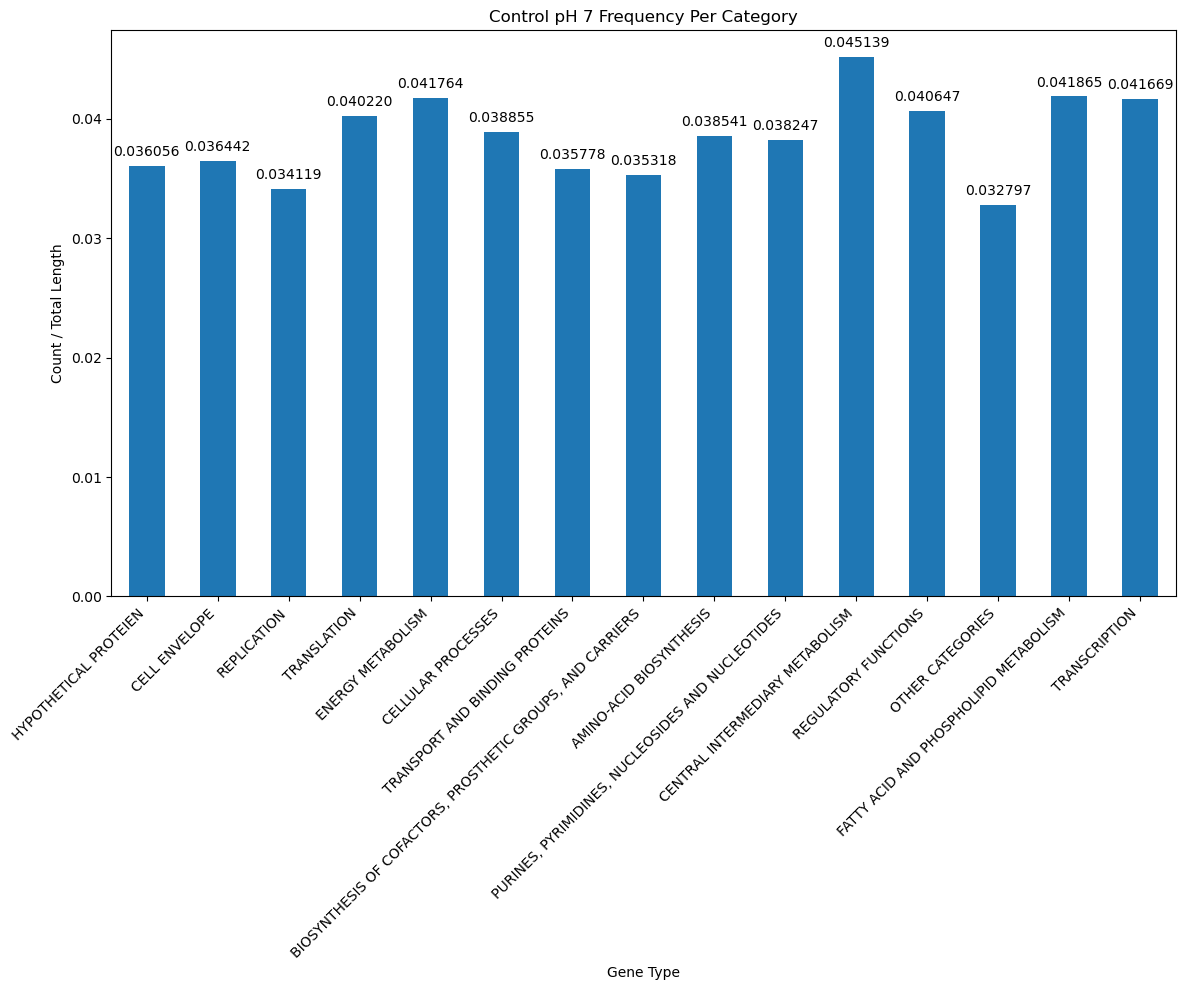

In [27]:
plt.figure(figsize=(12, 10))
ax = merged_df.set_index('gene_type')['adjusted_count'].plot(kind='bar')
plt.xlabel('Gene Type')
plt.ylabel('Count / Total Length')
plt.title('Control pH 7 Frequency Per Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.6f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

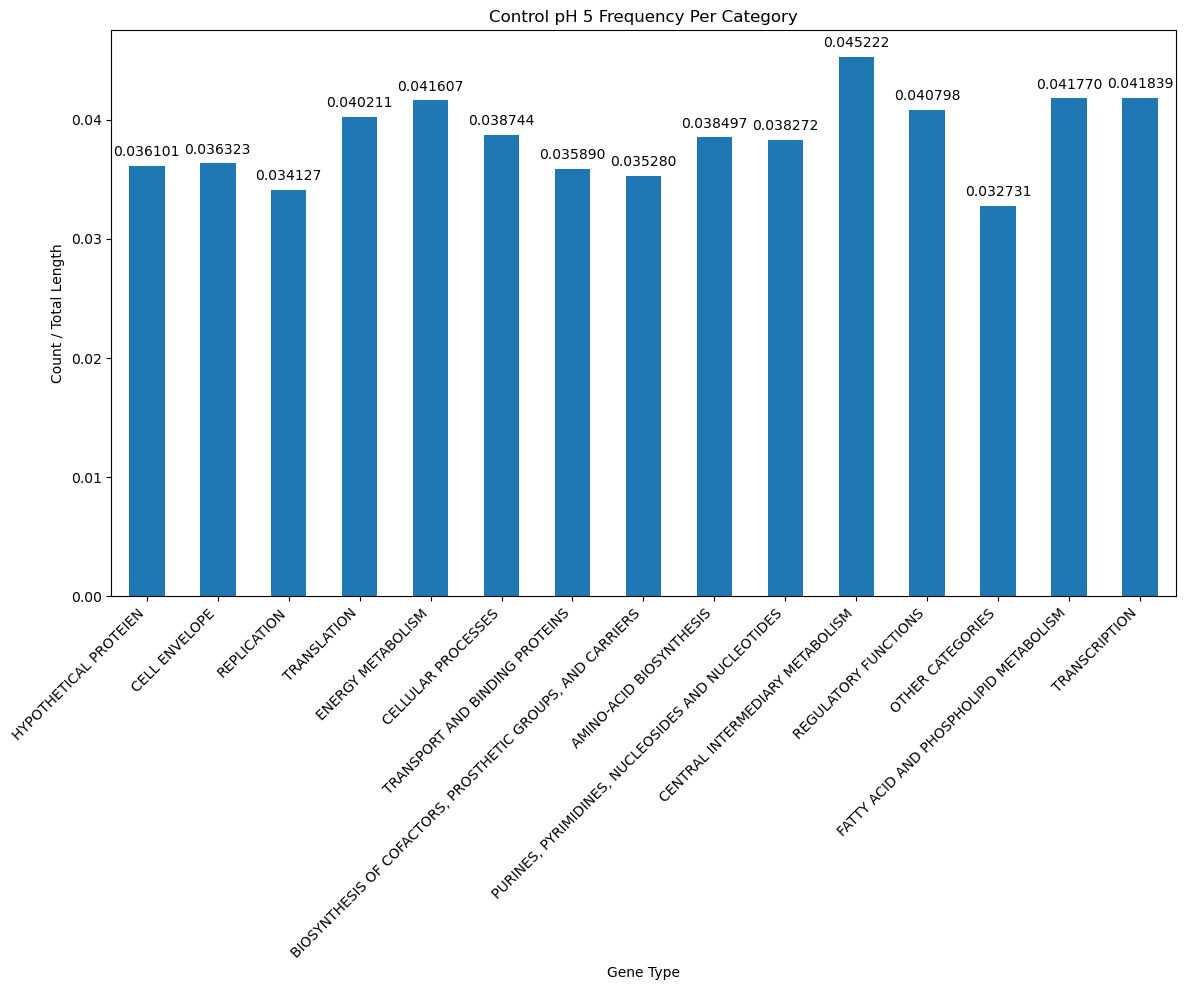

In [28]:
#histogram for ph 5
ctrl_5 = merged[merged['sample'] == 'ctrl pH5']
ctr5_merg = ctrl_5.merge(category_lengths_df, left_on='gene_type', right_on='Category')

gene_type_counts = ctrl_5['gene_type'].value_counts().reset_index()
gene_type_counts.columns = ['gene_type', 'count']
ctr5_merg = gene_type_counts.merge(category_lengths_df, left_on='gene_type', right_on='Category')
ctr5_merg['adjusted_count'] = ctr5_merg['count'] / ctr5_merg['Total_Length']

plt.figure(figsize=(12, 10))
ax = ctr5_merg.set_index('gene_type')['adjusted_count'].plot(kind='bar')
plt.xlabel('Gene Type')
plt.ylabel('Count / Total Length')
plt.title('Control pH 5 Frequency Per Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.6f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

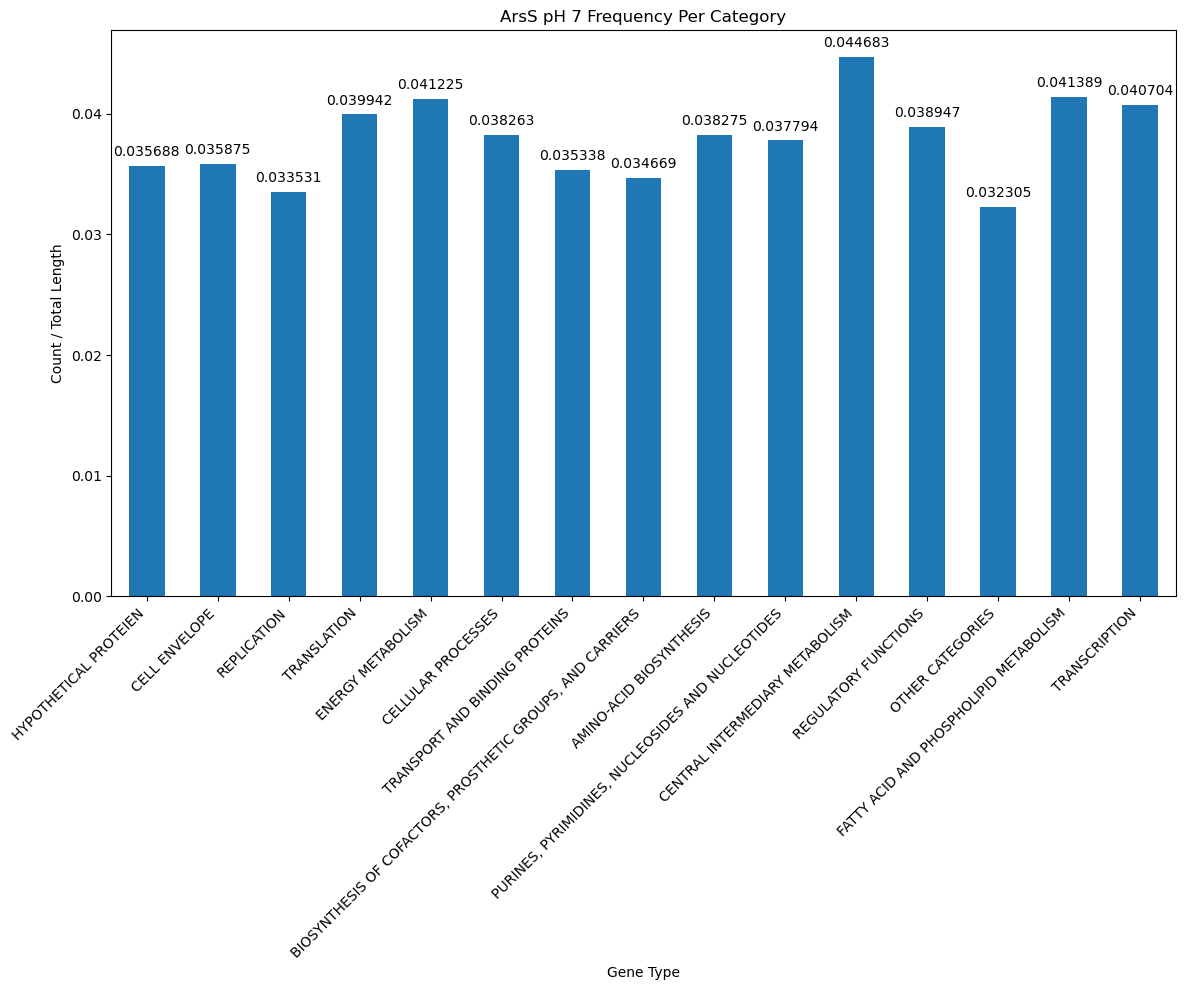

In [29]:
#histogram for ars 6
ars_7 = merged[merged['sample'] == 'arsS pH7']
ars7_merg = ars_7.merge(category_lengths_df, left_on='gene_type', right_on='Category')

gene_type_counts = ars_7['gene_type'].value_counts().reset_index()
gene_type_counts.columns = ['gene_type', 'count']
ars7_merg = gene_type_counts.merge(category_lengths_df, left_on='gene_type', right_on='Category')
ars7_merg['adjusted_count'] = ars7_merg['count'] / ars7_merg['Total_Length']

plt.figure(figsize=(12, 10))
ax = ars7_merg.set_index('gene_type')['adjusted_count'].plot(kind='bar')
plt.xlabel('Gene Type')
plt.ylabel('Count / Total Length')
plt.title('ArsS pH 7 Frequency Per Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.6f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

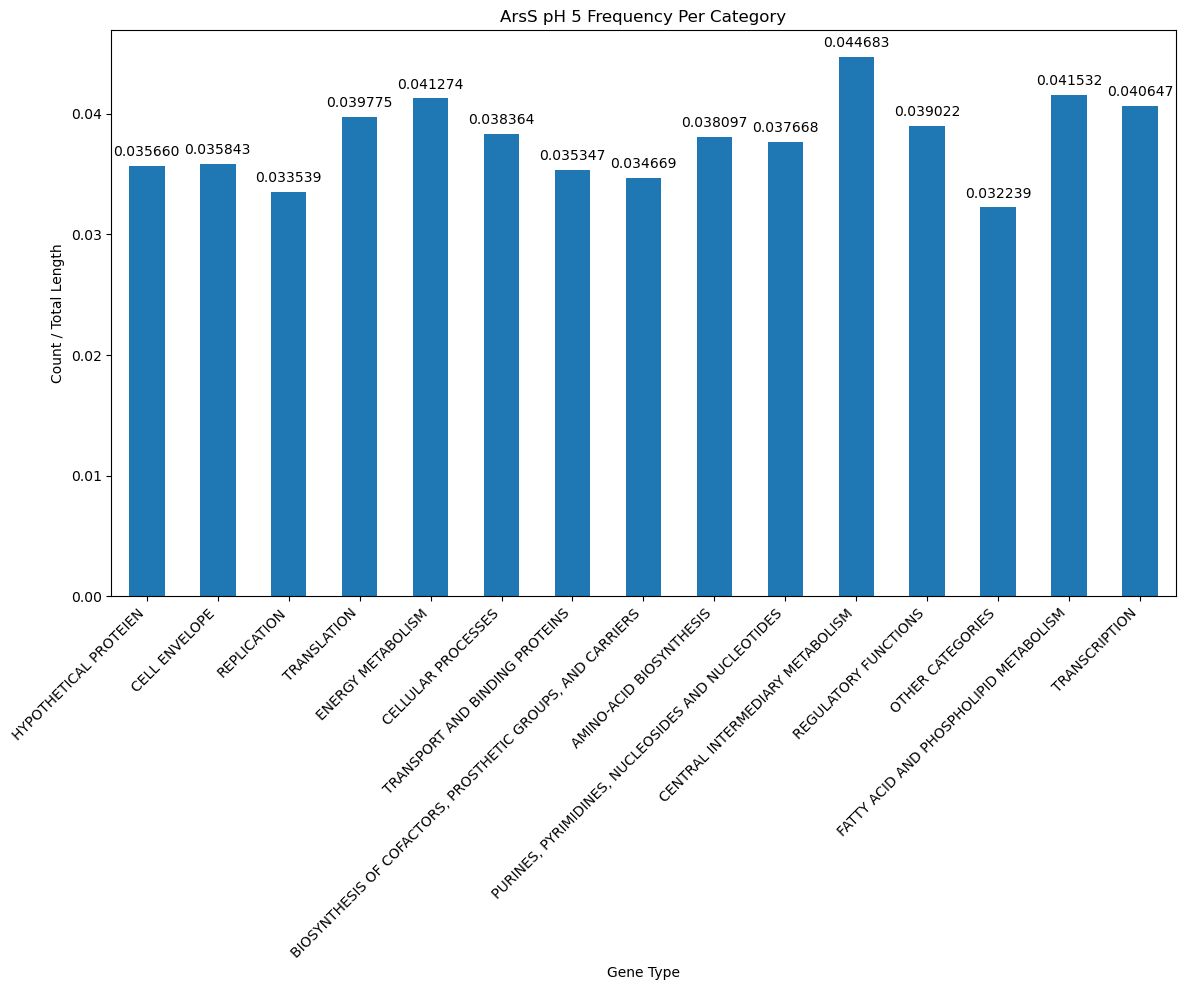

In [30]:
#histogram for ars 6
ars_5 = merged[merged['sample'] == 'arsS pH5']
ars5_merg = ars_5.merge(category_lengths_df, left_on='gene_type', right_on='Category')

gene_type_counts = ars_5['gene_type'].value_counts().reset_index()
gene_type_counts.columns = ['gene_type', 'count']
ars5_merg = gene_type_counts.merge(category_lengths_df, left_on='gene_type', right_on='Category')
ars5_merg['adjusted_count'] = ars5_merg['count'] / ars5_merg['Total_Length']

plt.figure(figsize=(12, 10))
ax = ars5_merg.set_index('gene_type')['adjusted_count'].plot(kind='bar')
plt.xlabel('Gene Type')
plt.ylabel('Count / Total Length')
plt.title('ArsS pH 5 Frequency Per Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.6f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

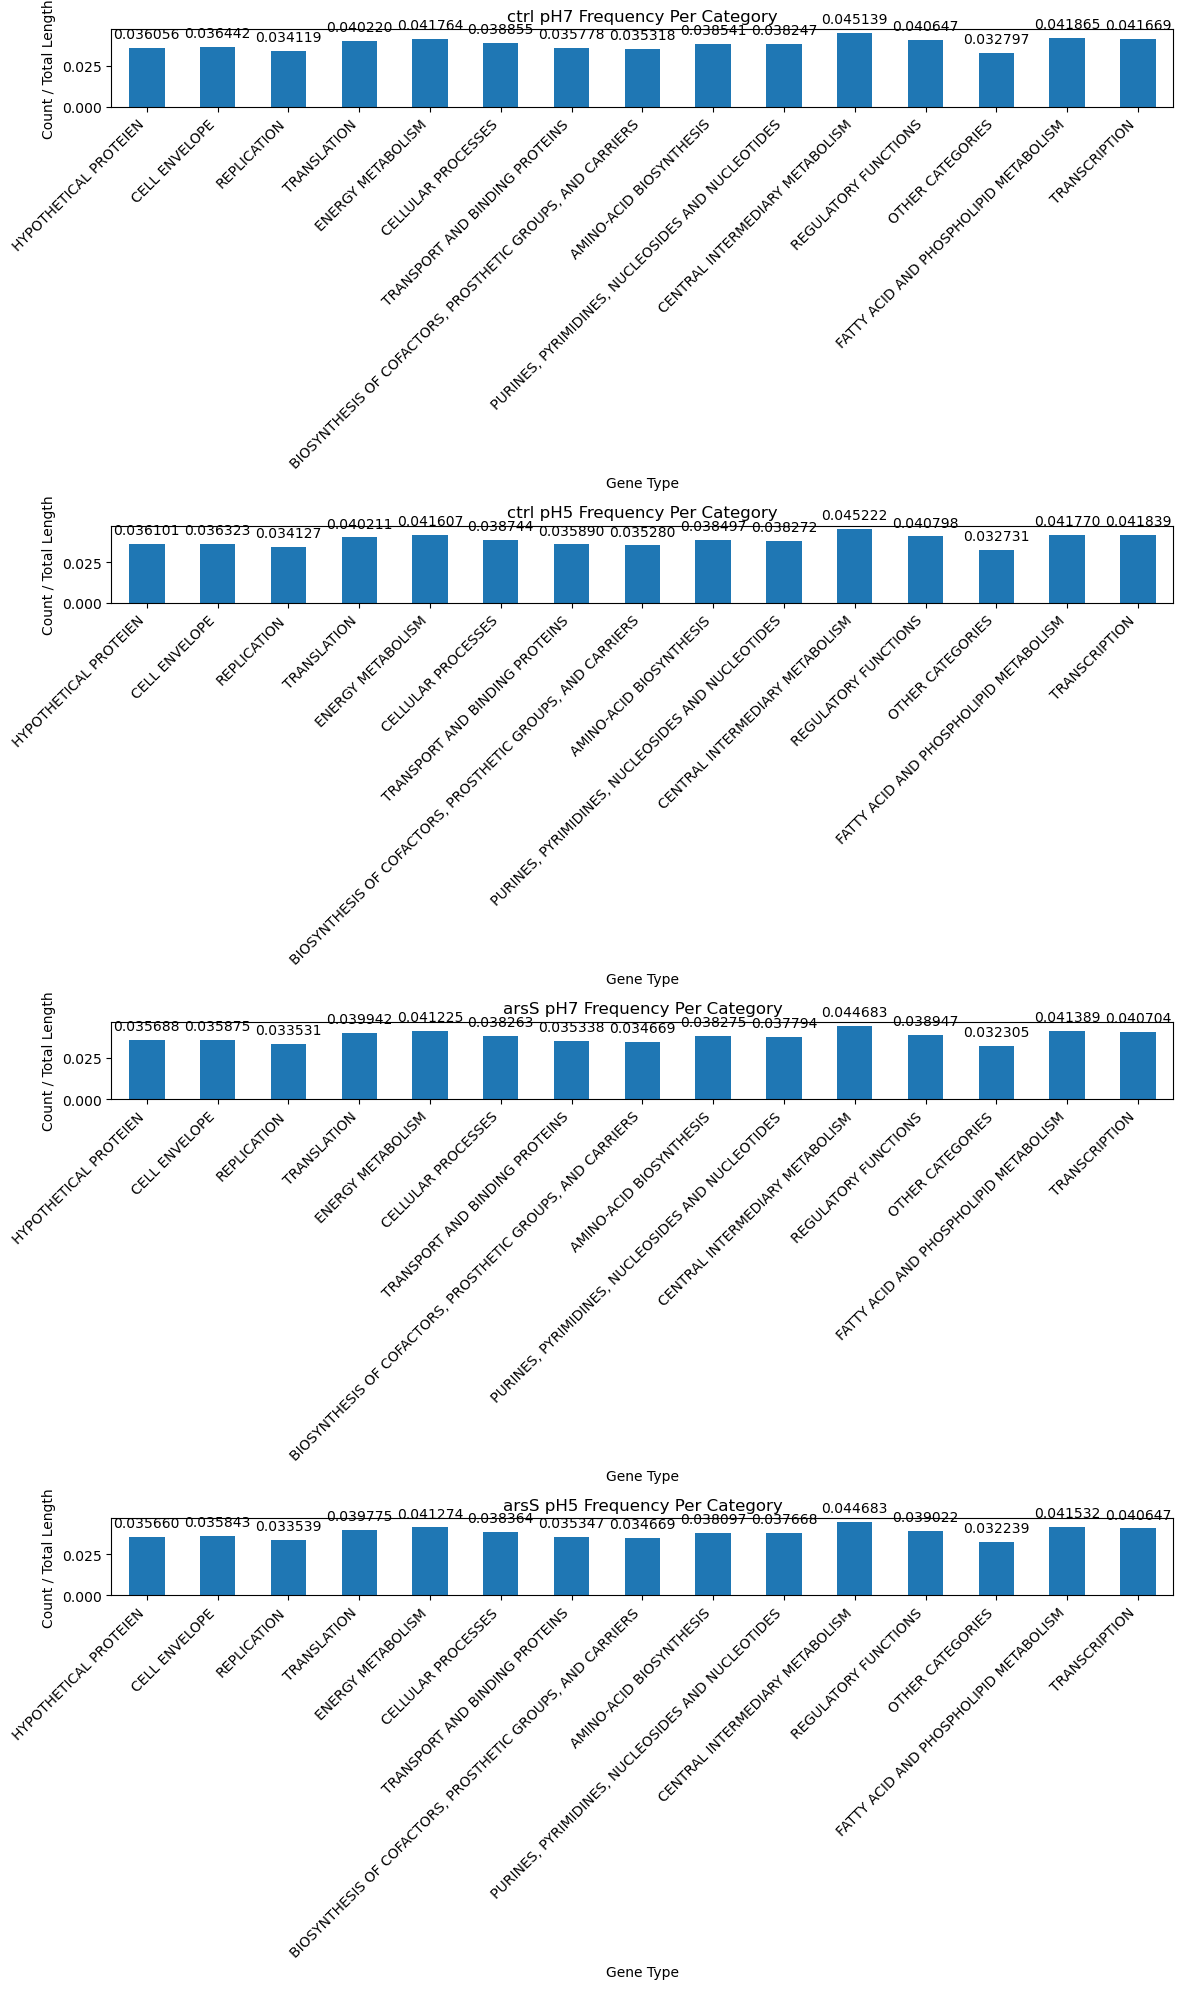

In [46]:
## unique histograms for each sample
import matplotlib.pyplot as plt

# getunique samples
samples = merged['sample'].unique()

fig, axes = plt.subplots(len(samples), 1, figsize=(12, len(samples) * 5))

#loop through each sample and generate a bar plot
for i, sample in enumerate(samples):
    sample_data = merged[merged['sample'] == sample]
    
    gene_type_counts = sample_data['gene_type'].value_counts().reset_index()
    gene_type_counts.columns = ['gene_type', 'count']
    sample_merg = gene_type_counts.merge(category_lengths_df, left_on='gene_type', right_on='Category')
    sample_merg['adjusted_count'] = sample_merg['count'] / sample_merg['Total_Length']

    ax = sample_merg.set_index('gene_type')['adjusted_count'].plot(kind='bar', ax=axes[i], title=f'{sample} Frequency Per Category')
    ax.set_xlabel('Gene Type')
    ax.set_ylabel('Count / Total Length')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.6f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

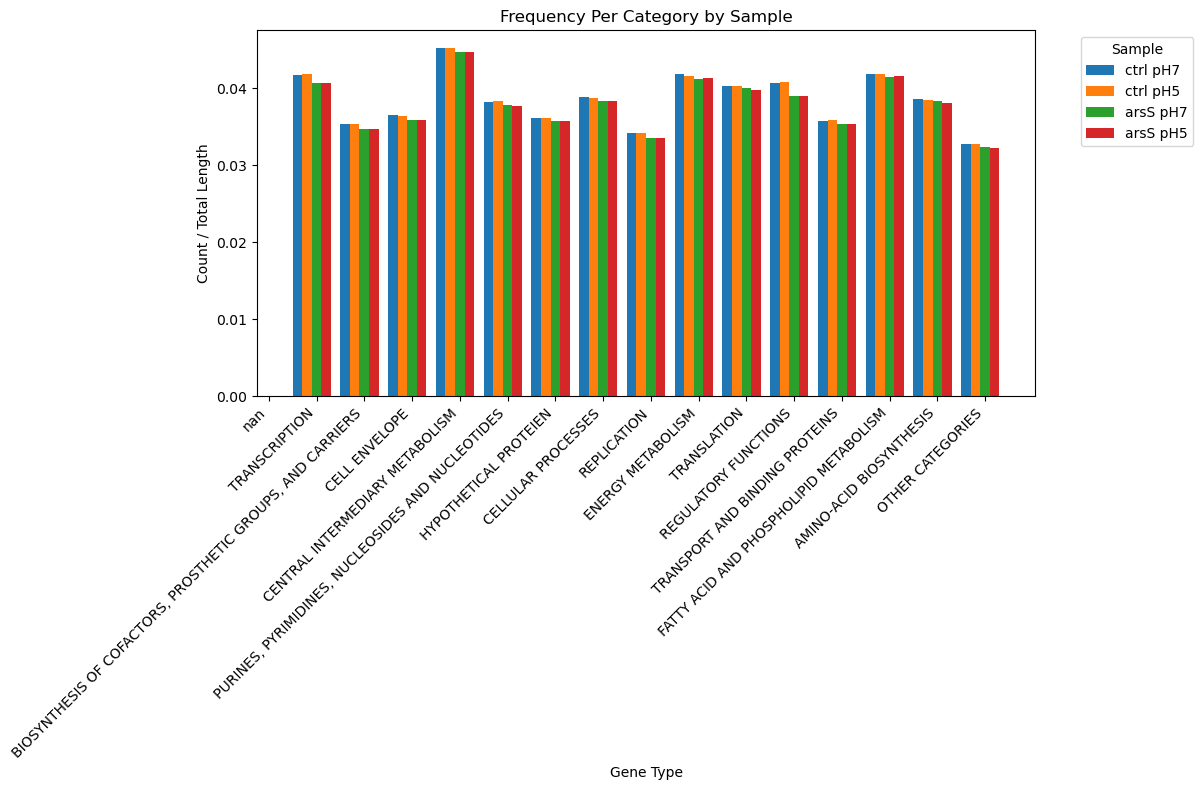

In [31]:
# Get unique samples and gene types
samples = merged['sample'].unique()
gene_types = merged['gene_type'].unique()

# Create a DataFrame to store adjusted counts for each sample and gene type
adjusted_counts_df = pd.DataFrame(index=gene_types, columns=samples)

# Loop through each sample, calculate adjusted counts, and store in the DataFrame
for sample in samples:
    sample_data = merged[merged['sample'] == sample]
    
    gene_type_counts = sample_data['gene_type'].value_counts().reset_index()
    gene_type_counts.columns = ['gene_type', 'count']
    
    sample_merg = gene_type_counts.merge(category_lengths_df, left_on='gene_type', right_on='Category')
    sample_merg['adjusted_count'] = sample_merg['count'] / sample_merg['Total_Length']
    
    # Store adjusted counts in the DataFrame
    adjusted_counts_df[sample] = adjusted_counts_df.index.map(
        dict(zip(sample_merg['gene_type'], sample_merg['adjusted_count']))
    )

# Plotting
plt.figure(figsize=(12, 8))

# Define positions for each group of bars
bar_width = 0.2  # Width of each bar
index = np.arange(len(gene_types))  # X-axis positions for each gene type

# Loop over samples to plot bars for each sample
for i, sample in enumerate(samples):
    plt.bar(index + i * bar_width, adjusted_counts_df[sample], bar_width, label=sample)

# Customize the plot
plt.xlabel('Gene Type')
plt.ylabel('Count / Total Length')
plt.title('Frequency Per Category by Sample')
plt.xticks(index + bar_width * (len(samples) / 2), gene_types, rotation=45, ha='right')
plt.legend(title='Sample', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()


In [22]:
summary_df

,1' pH7 density_mean,1' pH5 density_mean,16' pH7 density_mean,16' pH5 density_mean,1' pH7 density_std,1' pH5 density_std,16' pH7 density_std,16' pH5 density_std
gene_type,,,,,,,,
AMINO-ACID BIOSYNTHESIS,0.038609,0.038524,0.038362,0.038059,0.008382,0.008017,0.008368,0.007939
"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS",0.034934,0.034858,0.034302,0.034362,0.009617,0.009604,0.009373,0.009253
CELL ENVELOPE,0.036984,0.036838,0.036366,0.036331,0.008842,0.008759,0.008869,0.008885
CELLULAR PROCESSES,0.039368,0.039199,0.038677,0.038768,0.011799,0.011731,0.011376,0.011443
CENTRAL INTERMEDIARY METABOLISM,0.042946,0.043192,0.042811,0.042677,0.008757,0.009134,0.008940,0.008796
ENERGY METABOLISM,0.041379,0.041245,0.040826,0.040857,0.009170,0.009294,0.009078,0.009232
FATTY ACID AND PHOSPHOLIPID METABOLISM,0.041303,0.041274,0.040717,0.040875,0.012557,0.012438,0.012658,0.012931
HYPOTHETICAL PROTEIEN,0.036871,0.036891,0.036465,0.036460,0.014075,0.014112,0.014024,0.014041
OTHER CATEGORIES,0.032951,0.032827,0.032543,0.032472,0.009911,0.009632,0.009961,0.009731


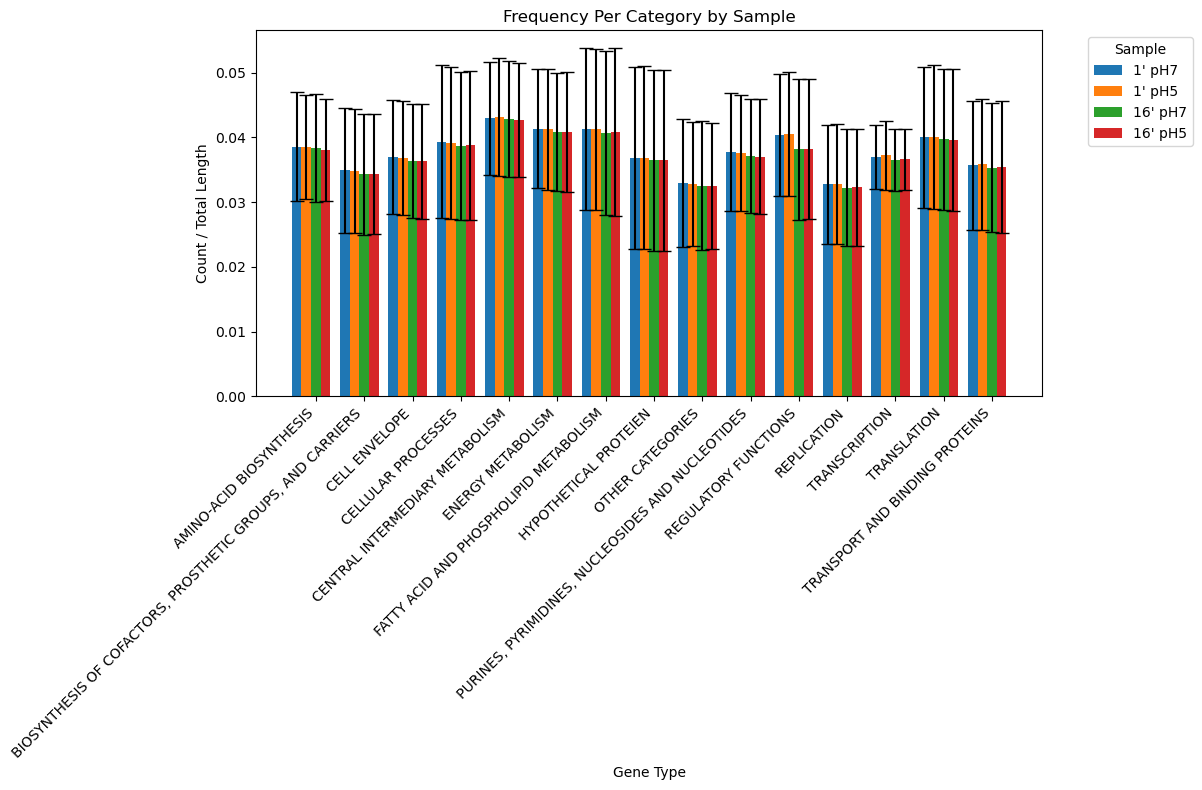

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming your summary_df has the mean and std for each sample like:
# '1\' pH7 density_mean', '1\' pH7 density_std', etc.

samples = ['1\' pH7', '1\' pH5', '16\' pH7', '16\' pH5']
gene_types = summary_df.index

# Create arrays for the mean and std values for each sample
mean_values = {
    sample: summary_df[f"{sample} density_mean"] for sample in samples
}
std_values = {
    sample: summary_df[f"{sample} density_std"] for sample in samples
}

# Plotting with error bars
plt.figure(figsize=(12, 8))

# Define positions for each group of bars
bar_width = 0.2  # Width of each bar
index = np.arange(len(gene_types))  # X-axis positions for each gene type

# Loop over samples to plot bars for each sample with error bars
for i, sample in enumerate(samples):
    plt.bar(index + i * bar_width, mean_values[sample], bar_width, label=sample,
            yerr=std_values[sample], capsize=5)  # capsize adds error bar caps

# Customize the plot
plt.xlabel('Gene Type')
plt.ylabel('Count / Total Length')
plt.title('Frequency Per Category by Sample')
plt.xticks(index + bar_width * (len(samples) / 2), gene_types, rotation=45, ha='right')
plt.legend(title='Sample', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()


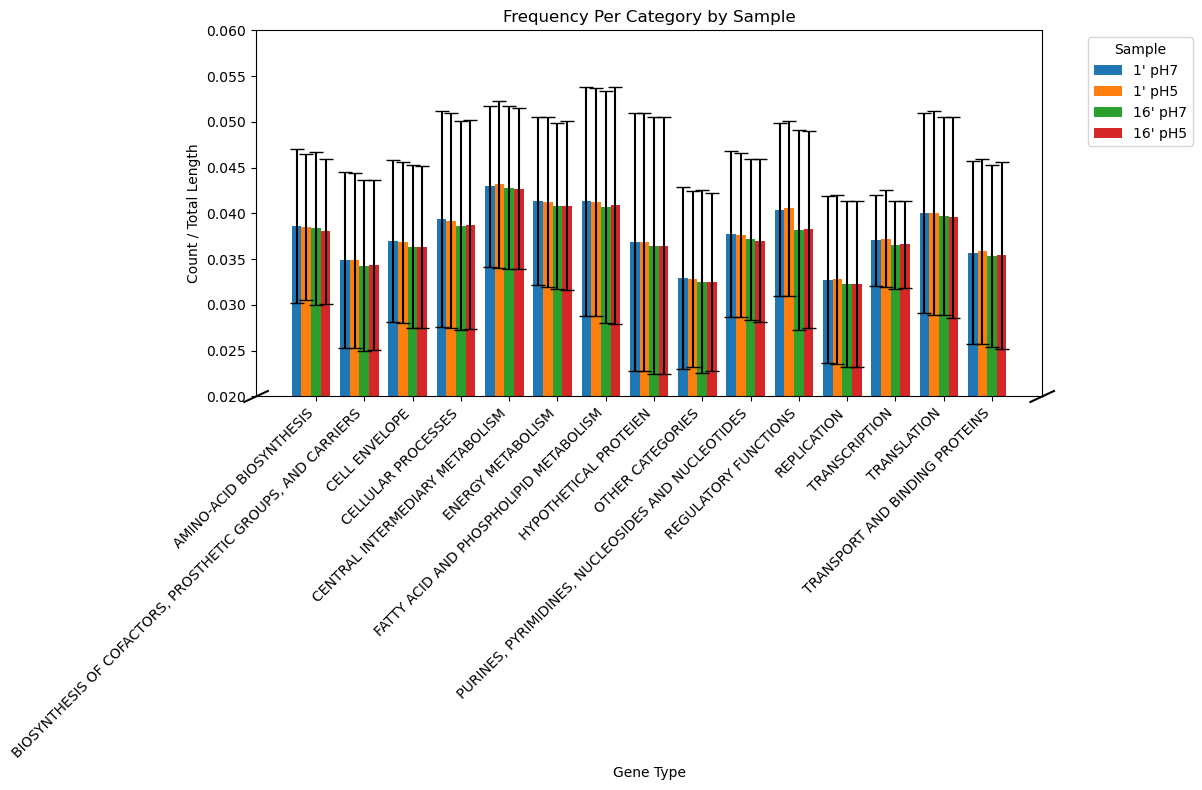

In [30]:
samples = ['1\' pH7', '1\' pH5', '16\' pH7', '16\' pH5']
gene_types = summary_df.index

# Create arrays for the mean and std values for each sample
mean_values = {
    sample: summary_df[f"{sample} density_mean"] for sample in samples
}
std_values = {
    sample: summary_df[f"{sample} density_std"] for sample in samples
}

# Plotting the bars
plt.figure(figsize=(12, 8))

# Define positions for each group of bars
bar_width = 0.2  # Width of each bar
index = np.arange(len(gene_types))  # X-axis positions for each gene type

# Loop over samples to plot bars for each sample with error bars
for i, sample in enumerate(samples):
    plt.bar(index + i * bar_width, mean_values[sample], bar_width, label=sample,
            yerr=std_values[sample], capsize=5)

# Set the y-axis limit to show values between 0.02 and 0.06
plt.ylim(0.02, 0.06)

# Add diagonal lines to indicate a break in the axis
d = 0.015  # Size of diagonal lines
kwargs = dict(transform=plt.gca().transAxes, color='k', clip_on=False)
plt.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
plt.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

# Customize the plot
plt.xlabel('Gene Type')
plt.ylabel('Count / Total Length')
plt.title('Frequency Per Category by Sample')
plt.xticks(index + bar_width * (len(samples) / 2), gene_types, rotation=45, ha='right')
plt.legend(title='Sample', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()
